**Setup toàn bộ môi trường + dataset + code**

In [1]:
# =========================================================
# CELL 1 - FULL SETUP COLAB
# =========================================================
# ===== ĐI VỀ /content =====
%cd /content
# ===== CHECK GPU =====
import torch

print("=" * 50)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("=" * 50)

# =========================================================
# CLONE GITHUB
# =========================================================

!git clone -b TN_B_ON https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git

# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================

!gdown --id 1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q dataset_BTXRD.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================

print("\nDATASET STRUCTURE:")
!ls dataset_BTXRD

# =========================================================
# COPY DATASET VÀO PROJECT
# =========================================================

!mv dataset_BTXRD Prompt-Guided-XRay-Segmentation/

# =========================================================
# ĐI VÀO PROJECT
# =========================================================

%cd Prompt-Guided-XRay-Segmentation

# =========================================================
# INSTALL REQUIREMENTS
# =========================================================

!pip install -q tqdm opencv-python matplotlib scikit-image gdown

print("\nSETUP DONE!")

/content
CUDA: True
GPU: Tesla T4
Cloning into 'Prompt-Guided-XRay-Segmentation'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (85/85), done.
remote: Total 183 (delta 64), reused 86 (delta 36), pack-reused 62 (from 1)
Receiving objects: 100% (183/183), 36.63 MiB | 16.49 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3
From (redirected): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3&confirm=t&uuid=990c2857-3470-46d1-83a4-1844d7adab3a
To: /content/dataset_BTXRD.zip
100% 1.50G/1.50G [00:11<00:00, 125MB/s]

DATASET STRUCTURE:
test  train  val
/content/Prompt-Guided-XRay-Segmentat

**Train**

In [ ]:
# =========================================================
# TRAIN
# =========================================================

!python train.py

Thí nghiệm B | Device: cuda | EncoderPrompt: True
Epoch 1/100 [Train]:   1% 6/465 [00:04<05:42,  1.34it/s, loss=1.6157]
Traceback (most recent call last):
  File "/content/Prompt-Guided-XRay-Segmentation/train.py", line 240, in <module>
    main()
  File "/content/Prompt-Guided-XRay-Segmentation/train.py", line 179, in main
    train_loss += loss.item()
                  ^^^^^^^^^^^
KeyboardInterrupt


**Checkpoint_PGA**

In [4]:
# @title
# ====== TẢI FILE TỪ GOOGLE DRIVE VÀ LƯU VÀO PATH A ======

# Cài thư viện
!pip install -q gdown

import gdown
import os

# ====== PATH LƯU ======
SAVE_DIR = "checkpoints/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ====== FILE ID GOOGLE DRIVE ======
file_id = "1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z"

# ====== FILE OUTPUT ======
output_path = os.path.join(SAVE_DIR, "pga_unet_expB_best.pth")

# ====== DOWNLOAD ======
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, output_path, quiet=False)

print(f"\n✅ Đã lưu tại: {output_path}")

Downloading...
From: https://drive.google.com/uc?id=1Mv-rUPI7KGmYemd27hmKbJQRHc4ZKB9z
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_expB_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 84.5MB/s]


✅ Đã lưu tại: checkpoints/pga_unet_expB_best.pth


**Checkpoint_PL**

In [5]:
# @title
# ====== TẢI FILE TỪ GOOGLE DRIVE VÀ LƯU VÀO PATH A ======

# Cài thư viện
!pip install -q gdown

import gdown
import os

# ====== PATH LƯU ======
SAVE_DIR = "checkpoints/"
os.makedirs(SAVE_DIR, exist_ok=True)

# ====== FILE ID GOOGLE DRIVE ======
file_id = "1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx"

# ====== FILE OUTPUT ======
output_path = os.path.join(SAVE_DIR, "best_mobilenetv4.pth")

# ====== DOWNLOAD ======
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, output_path, quiet=False)

print(f"\n✅ Đã lưu tại: {output_path}")

Downloading...
From (original): https://drive.google.com/uc?id=1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx
From (redirected): https://drive.google.com/uc?id=1N-Xq4l3qOcwDhRCu5g-wFQindT8ubOgx&confirm=t&uuid=a658bc7c-cdaa-4c5a-a73c-20d85e3c5ac9
To: /content/Prompt-Guided-XRay-Segmentation/checkpoints/best_mobilenetv4.pth
100%|██████████| 39.7M/39.7M [00:00<00:00, 131MB/s]


✅ Đã lưu tại: checkpoints/best_mobilenetv4.pth


## Bước 2 – Thí nghiệm A (baseline sạch, zoom-out only)
# Trong train.py: EXPERIMENT='A', USE_ENCODER_PROMPT=False

In [ ]:
# @title
"""
test_exp_scenarios.py
=====================
Đánh giá 3 kịch bản prompt: 100% zoom-out | 100% shift | mixed 70-30
Visualize danh sách ảnh: mỗi ảnh hiện 2 kịch bản (zoom-out và shift)

Cách chạy:
    python test_exp_scenarios.py
"""

import os
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from scipy.ndimage import binary_erosion, distance_transform_edt

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CẤU HÌNH – chỉnh tại đây
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
BATCH_SIZE         = 4
USE_ENCODER_PROMPT = True   # ← True = bật encoder gate / False = tắt

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

# THAY ĐỔI: Danh sách 3 ảnh muốn visualize
VIS_IMAGES = [
    "IMG001768.png",
    "IMG001538.png",
    "IMG001100.png"
]

# =========================================================
# METRIC HELPERS & POST-PROCESSING
# =========================================================

def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    """
    Giữ lại vùng liên thông lớn nhất (Largest Connected Component).
    Lọc sạch các điểm nhiễu vụn hoặc đường viền artifact do model sinh ra.
    """
    if binary_map.sum() == 0:
        return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:  # Chỉ có nền (background)
        return binary_map

    # Tìm label có diện tích (area) lớn nhất, bỏ qua label 0 (nền)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_hd95(pred: np.ndarray, gt: np.ndarray) -> float:
    """95% Hausdorff Distance (pixel). Thấp hơn = tốt hơn."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any():
        return 0.0
    if not pred.any() or not gt.any():
        return float(IMG_SIZE)
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2):
        return float(IMG_SIZE)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    """
    Center-Based Localization [0,1]. Cao hơn = tốt hơn.
    Trả về None nếu GT rỗng (sample bị bỏ qua khi tính mean).
    """
    if gt_bin.sum() == 0:
        return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 +
                      (xs.max() - xs.min()) ** 2) + 1e-6
    if pred_bin.sum() == 0:
        return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 +
                (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def get_centroid(binary_map: np.ndarray):
    """
    Tính tâm của binary mask trên không gian 512x512.
    Trả về (cx, cy) – cx là trục ngang (cột), cy là trục dọc (hàng).
    Trả về (None, None) nếu mask rỗng.
    """
    if binary_map.sum() == 0:
        return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())   # (cx, cy)

# =========================================================
# ĐÁNH GIÁ 1 KỊCH BẢN
# =========================================================

def run_eval(model: torch.nn.Module, prompt_mode: str) -> dict:
    """Chạy inference toàn bộ test set, trả về dict 6 metric."""
    ds = BTXRD_Dataset(
        image_dir=TEST_IMAGE_DIR,
        json_dir=TEST_JSON_DIR,
        img_size=IMG_SIZE,
        is_train=False,
        prompt_mode=prompt_mode,
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    smooth = 1e-5
    all_dice, all_iou, all_pre, all_rec, all_hd95, all_cbl = [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for images, masks, prompts in loader:
            images  = images.to(DEVICE)
            masks   = masks.to(DEVICE)
            prompts = prompts.to(DEVICE)
            preds   = (torch.sigmoid(model(images, prompts)) > 0.5).float()

            for b in range(images.size(0)):
                pm = preds[b, 0].cpu().numpy()          # predicted mask (512x512)
                gm = masks[b, 0].cpu().numpy()           # GT mask (512x512)

                # --- ÁP DỤNG HẬU XỬ LÝ LỌC NHIỄU BIÊN ---
                pm = extract_lcc(pm)

                tp = (pm * gm).sum()
                fp = (pm * (1 - gm)).sum()
                fn = ((1 - pm) * gm).sum()

                all_dice.append((2 * tp + smooth) / (2 * tp + fp + fn + smooth))
                all_iou.append( (tp + smooth) / (tp + fp + fn + smooth))
                all_pre.append( (tp + smooth) / (tp + fp + smooth))
                all_rec.append( (tp + smooth) / (tp + fn + smooth))
                all_hd95.append(calc_hd95(pm.astype(bool), gm.astype(bool)))

                cbl = calc_cbl(pm.astype(bool), gm.astype(bool))
                if cbl is not None:
                    all_cbl.append(cbl)

    return {
        'dice': np.mean(all_dice),
        'iou':  np.mean(all_iou),
        'pre':  np.mean(all_pre),
        'rec':  np.mean(all_rec),
        'hd95': np.mean(all_hd95),
        'cbl':  np.mean(all_cbl) if all_cbl else 0.0,
        'n':    len(all_dice),
    }

# =========================================================
# ĐÁNH GIÁ 3 KỊCH BẢN
# =========================================================

def evaluate_all(model: torch.nn.Module) -> dict:
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    print("\n" + "=" * 72)
    print(f"  ĐÁNH GIÁ 3 KỊCH BẢN  |  encoder_prompt = {enc_tag}")
    print("=" * 72)

    scenarios = {
        '100% Zoom-out': 'zoom_out',
        '100% Shift':    'shift',
        'Mixed 70-30':   'mixed_7_3',
    }

    results = {}
    for name, mode in scenarios.items():
        results[name] = run_eval(model, mode)
        print(f"  [{name}]  {results[name]['n']} samples – xong.")

    # In bảng kết quả
    header = (f"\n{'Kịch bản':<16} {'Dice↑':>7} {'IoU↑':>7} "
              f"{'Pre↑':>7} {'Rec↑':>7} {'HD95↓':>8} {'CBL↑':>7} {'N':>5}")
    print(header)
    print("-" * 68)
    for name, r in results.items():
        print(f"{name:<16} {r['dice']:>7.4f} {r['iou']:>7.4f} "
              f"{r['pre']:>7.4f} {r['rec']:>7.4f} "
              f"{r['hd95']:>8.2f} {r['cbl']:>7.4f} {r['n']:>5}")
    return results

# =========================================================
# VISUALIZE 1 ẢNH – 2 KỊCH BẢN (zoom-out & shift)
# =========================================================

def visualize_two_scenarios(model: torch.nn.Module, img_name: str):
    # ── Đọc ảnh và annotation ─────────────────────────────
    img_path  = os.path.join(TEST_IMAGE_DIR, img_name)
    json_path = os.path.join(TEST_JSON_DIR, os.path.splitext(img_name)[0] + '.json')
    if not os.path.exists(img_path):
        print(f"  ⚠  Không tìm thấy: {img_path}")
        return

    image_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    orig_h, orig_w = image_cv.shape

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Lấy polygon đầu tiên hợp lệ
    target_shape = next(
        (s for s in data.get('shapes', [])
         if s.get('shape_type') == 'polygon' and len(s.get('points', [])) > 2),
        data['shapes'][0] if data.get('shapes') else None
    )
    if target_shape is None:
        print(f"  ⚠  Không tìm thấy polygon trong {img_name}")
        return

    points = np.array(target_shape['points'])
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    gt_w,  gt_h  = x_max - x_min, y_max - y_min

    # GT mask gốc (để resize)
    mask_cv = np.zeros((orig_h, orig_w), dtype=np.uint8)
    cv2.fillPoly(mask_cv, [points.astype(np.int32)], 255)

    # Dùng Dataset helper để tạo heatmap đồng nhất với training
    ds_h = BTXRD_Dataset(
        TEST_IMAGE_DIR, TEST_JSON_DIR,
        img_size=IMG_SIZE, is_train=False
    )
    r = (ds_h.zoom_ratio[0] + ds_h.zoom_ratio[1]) / 2   # ratio cố định cho test

    def make_heatmap(bx0, bx1, by0, by1):
        """Tạo heatmap rồi resize về 512x512."""
        pm = ds_h.create_plateau_heatmap(
            [bx0, by0, bx1, by1], orig_h, orig_w
        )
        return cv2.resize(pm, (IMG_SIZE, IMG_SIZE))

    # ── Prompt zoom-out: mở rộng đều 4 phía ──────────────
    pm_zoom = make_heatmap(
        max(0,      x_min - gt_w * r),
        min(orig_w, x_max + gt_w * r),
        max(0,      y_min - gt_h * r),
        min(orig_h, y_max + gt_h * r),
    )

    # ── Prompt shift: dịch tâm sang phải + xuống, vẫn overlap GT ──
    shift_x = gt_w * ds_h.shift_ratio * 0.6   # 60% max shift → fixed cho test
    shift_y = gt_h * ds_h.shift_ratio * 0.4
    new_cx  = (x_min + x_max) / 2 + shift_x
    new_cy  = (y_min + y_max) / 2 + shift_y
    half_w  = gt_w * (1 + r) / 2
    half_h  = gt_h * (1 + r) / 2
    pm_shift = make_heatmap(
        max(0,      new_cx - half_w),
        min(orig_w, new_cx + half_w),
        max(0,      new_cy - half_h),
        min(orig_h, new_cy + half_h),
    )

    # ── Resize ảnh & mask về 512x512 ─────────────────────
    image_r = cv2.resize(image_cv, (IMG_SIZE, IMG_SIZE))
    mask_r  = cv2.resize(mask_cv,  (IMG_SIZE, IMG_SIZE),
                         interpolation=cv2.INTER_NEAREST)
    img_np  = image_r / 255.0
    gt_np   = (mask_r > 127).astype(np.float32)

    img_t = torch.from_numpy(
        (image_r.astype(np.float32) / 255.0 - 0.5) / 0.5
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)

    # Tâm GT tính trên không gian 512x512
    cx_gt, cy_gt = get_centroid(gt_np.astype(bool))

    # ── Vẽ figure ────────────────────────────────────────
    scenarios_vis = [
        ('Zoom-out (fixed)', pm_zoom),
        ('Shift (fixed)',    pm_shift),
    ]

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    enc_tag = 'ON' if USE_ENCODER_PROMPT else 'OFF'
    fig.suptitle(
        f"Thí nghiệm A/B – Zoom-out vs Shift  |  {img_name}  |  encoder={enc_tag}",
        fontsize=14, fontweight='bold'
    )
    col_titles = ["Ảnh gốc", "Prompt heatmap", "Ground Truth", "Dự đoán",
                  "Biên + Tâm (Dice | HD95 | CBL)"]
    for c, t in enumerate(col_titles):
        axes[0][c].set_title(t, fontsize=11, fontweight='bold')

    model.eval()
    with torch.no_grad():
        for row, (scenario_name, pm_np) in enumerate(scenarios_vis):
            pm_t = torch.from_numpy(pm_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
            pred_np = (torch.sigmoid(model(img_t, pm_t)) > 0.5).float()[0, 0].cpu().numpy()

            # --- ÁP DỤNG HẬU XỬ LÝ LỌC NHIỄU BIÊN TRƯỚC KHI VẼ ---
            pred_np = extract_lcc(pred_np)

            # Tâm dự đoán – tính trên 512x512 sau khi đã lọc nhiễu
            cx_pred, cy_pred = get_centroid(pred_np.astype(bool))

            tp   = (pred_np * gt_np).sum()
            dice = (2 * tp + 1e-5) / (pred_np.sum() + gt_np.sum() + 1e-5)
            hd95 = calc_hd95(pred_np.astype(bool), gt_np.astype(bool))
            cbl  = calc_cbl(pred_np.astype(bool),  gt_np.astype(bool)) or 0.0

            # Col 0: Ảnh gốc
            axes[row][0].imshow(img_np, cmap='gray')
            axes[row][0].set_ylabel(scenario_name, fontsize=11, fontweight='bold',
                                    rotation=0, labelpad=72, va='center')

            # Col 1: Prompt heatmap
            axes[row][1].imshow(img_np, cmap='gray')
            axes[row][1].imshow(
                np.ma.masked_where(pm_np < 0.05, pm_np),
                cmap='magma', alpha=0.65
            )

            # Col 2: Ground Truth overlay xanh + contour + tâm GT
            axes[row][2].imshow(img_np, cmap='gray')
            green = np.zeros((*gt_np.shape, 4), dtype=np.float32)
            green[gt_np == 1] = [0, 1, 0, 0.35]
            axes[row][2].imshow(green)
            if gt_np.max() > 0:
                axes[row][2].contour(gt_np, [0.5], colors='lime', linewidths=1.5)
            if cx_gt is not None:
                axes[row][2].plot(
                    cx_gt, cy_gt, 'o',
                    color='lime', ms=9,
                    markeredgecolor='black', markeredgewidth=1.2,
                    label='Tâm GT'
                )
                axes[row][2].legend(fontsize=7, loc='lower right')

            # Col 3: Dự đoán overlay đỏ + contour + tâm pred
            axes[row][3].imshow(img_np, cmap='gray')
            red = np.zeros((*pred_np.shape, 4), dtype=np.float32)
            red[pred_np == 1] = [1, 0, 0, 0.35]
            axes[row][3].imshow(red)
            if pred_np.max() > 0:
                axes[row][3].contour(pred_np, [0.5], colors='red', linewidths=1.5)
            if cx_pred is not None:
                axes[row][3].plot(
                    cx_pred, cy_pred, 'o',
                    color='red', ms=9,
                    markeredgecolor='white', markeredgewidth=1.2,
                    label='Tâm Pred'
                )
                axes[row][3].legend(fontsize=7, loc='lower right')

            # Col 4: Biên GT (xanh) + Biên Pred (đỏ nét đứt)
            #        + tâm GT + tâm Pred + đường nối 2 tâm
            axes[row][4].imshow(img_np, cmap='gray')
            if gt_np.max() > 0:
                axes[row][4].contour(gt_np,   [0.5],
                                     colors='lime', linewidths=2)
            if pred_np.max() > 0:
                axes[row][4].contour(pred_np, [0.5],
                                     colors='red', linewidths=2,
                                     linestyles='--')
            if cx_gt is not None:
                axes[row][4].plot(cx_gt, cy_gt, 'o',
                                  color='lime', ms=8,
                                  markeredgecolor='black', markeredgewidth=1.2,
                                  label='Tâm GT')
            if cx_pred is not None:
                axes[row][4].plot(cx_pred, cy_pred, 'o',
                                  color='red', ms=8,
                                  markeredgecolor='white', markeredgewidth=1.2,
                                  label='Tâm Pred')
            # Đường nối 2 tâm → thấy trực quan độ lệch CBL
            if cx_gt is not None and cx_pred is not None:
                axes[row][4].plot(
                    [cx_gt, cx_pred], [cy_gt, cy_pred],
                    '--', color='yellow', lw=1.5, alpha=0.85
                )
            axes[row][4].set_title(
                f"Dice:{dice:.3f} | HD95:{hd95:.1f}px | CBL:{cbl:.3f}",
                fontsize=9, fontweight='bold'
            )
            axes[row][4].legend(fontsize=7, loc='lower right')

            for ax in axes[row]:
                ax.axis('off')

    plt.tight_layout()
    plt.show()

# =========================================================
# ENTRY POINT
# =========================================================
if __name__ == "__main__":
    model = PGA_UNet(
        in_channels=1,
        n_classes=1,
        use_encoder_prompt=USE_ENCODER_PROMPT
    ).to(DEVICE)
    model.load_state_dict(
        torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    )
    model.eval()
    print(f"Model loaded: {MODEL_PATH}")
    print(f"Device: {DEVICE}  |  Encoder prompt: {'ON' if USE_ENCODER_PROMPT else 'OFF'}")

    # 1. Đánh giá số liệu 3 kịch bản
    results = evaluate_all(model)

    # 2. Lưu kết quả CSV
    import csv
    os.makedirs("results", exist_ok=True)
    csv_path = "results/pga_unet_expB_results.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["model", "prompt_mode", "dice", "iou", "precision", "recall", "hd95", "cbl", "n_samples"])
        mode_map = {"100% Zoom-out": "zoom_out", "100% Shift": "shift", "Mixed 70-30": "mixed_7_3"}
        for name, r in results.items():
            writer.writerow([
                "PGA-UNet Exp B",
                mode_map.get(name, name),
                f"{r['dice']:.4f}", f"{r['iou']:.4f}",
                f"{r['pre']:.4f}",  f"{r['rec']:.4f}",
                f"{r['hd95']:.4f}", f"{r['cbl']:.4f}",
                r["n"]
            ])
    print(f"\nKet qua da luu: {csv_path}")

    # 3. Vòng lặp show 3 ảnh, mỗi ảnh 2 kịch bản
    for img_name in VIS_IMAGES:
        visualize_two_scenarios(model, img_name)

**Thí nghiệm prompt 70% vùng đen để bật phòng vệ**

In [ ]:
# @title
import os
import cv2
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# 1. CẤU HÌNH HỆ THỐNG
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
USE_ENCODER_PROMPT = True

CONFIDENCE_THRESHOLD = 0.80
CENTER_DIST_RATIO    = 0.25
DARK_PIXEL_THRESHOLD = -0.80 # Điểm ảnh có cường độ < -0.80 trên scale [-1, 1] (gần đen tuyệt đối)
DARK_RATIO_LIMIT     = 0.70  # Prompt chứa > 70% vùng đen -> Kích hoạt phòng vệ

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"
VIS_IMAGES     = ["IMG001768.png", "IMG001538.png", "IMG001100.png"]

# =========================================================
# 2. HELPERS
# =========================================================
def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

def calc_cbl_point(px: float, py: float, gt_bin: np.ndarray):
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + 1e-6
    cx_gt, cy_gt = float(xs.mean()), float(ys.mean())
    d = np.sqrt((px - cx_gt) ** 2 + (py - cy_gt) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def compute_gradcam(model, image_tensor):
    gradients, activations = [], []
    def fwd_hook(module, inp, out):
        activations.append(out)
        out.register_hook(lambda g: gradients.append(g))
    hook = model.center.register_forward_hook(fwd_hook)
    model.eval()
    img_t = image_tensor.clone().detach().to(DEVICE)
    zero_prompt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = model(img_t, zero_prompt)
    model.zero_grad()
    out.sum().backward()
    hook.remove()
    if not gradients: return None
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# =========================================================
# 3. LÕI KIỂM DUYỆT (THAY ĐỔI LOGIC BẮT VÙNG ĐEN)
# =========================================================
def predict_with_check(model, img_tensor, prompt_tensor):
    model.eval()

    with torch.no_grad():
        out  = model(img_tensor.to(DEVICE), prompt_tensor.to(DEVICE))
        prob = torch.sigmoid(out)
        pred = (prob > 0.5).float()

    conf     = prob.max().item()
    pm_np    = prompt_tensor[0, 0].numpy()
    pr_np    = pred[0, 0].cpu().numpy()
    img_np   = img_tensor[0, 0].numpy()
    prob_np  = prob[0, 0].cpu().numpy()

    ys_p, xs_p = np.where(pm_np > 0.3)
    cx_pmt = xs_p.mean() if len(xs_p) > 0 else IMG_SIZE / 2
    cy_pmt = ys_p.mean() if len(ys_p) > 0 else IMG_SIZE / 2
    prompt_area = len(xs_p)

    cx_pr, cy_pr = get_centroid(pr_np)
    pred_area    = int(pr_np.sum())

    dist_pred_pmt = (np.sqrt((cx_pr - cx_pmt)**2 + (cy_pr - cy_pmt)**2)
                     if cx_pr is not None else IMG_SIZE)

    # --- BỘ QUY TẮC MỚI ---
    suspicious_conf = conf < CONFIDENCE_THRESHOLD
    suspicious_dist = dist_pred_pmt > (IMG_SIZE * CENTER_DIST_RATIO)
    suspicious_area = pred_area < 50

    suspicious_ratio = False
    if prompt_area > 0 and (pred_area / float(prompt_area)) < 0.05:
        suspicious_ratio = True

    # KIỂM TRA TỶ LỆ VÙNG ĐEN TRONG PROMPT (Đúng ý của bạn)
    prompt_mask = pm_np > 0.3
    if prompt_mask.sum() > 0:
        dark_pixels = (img_np[prompt_mask] < DARK_PIXEL_THRESHOLD).sum()
        dark_ratio  = dark_pixels / prompt_mask.sum()
        suspicious_dark_bg = dark_ratio > DARK_RATIO_LIMIT
    else:
        suspicious_dark_bg = True
        dark_ratio = 1.0

    reasons = {
        "LOW_CONF"    : suspicious_conf,
        "FAR_DIST"    : suspicious_dist,
        "TINY_AREA"   : suspicious_area,
        "TINY_RATIO"  : suspicious_ratio,
        "DARK_BG_70%" : suspicious_dark_bg  # Bật cờ nếu > 70% vùng đen
    }

    is_suspicious = any(reasons.values())

    if is_suspicious:
        pr_np = np.zeros_like(pr_np)
        cx_pr = cy_pr = None
        sal_out = compute_gradcam(model, img_tensor) # Chỉ tính Gradcam khi cần cứu hộ
    else:
        sal_out = None

    return dict(mask=pr_np, prob_map=prob_np, confidence=conf,
                center_dist=dist_pred_pmt, cx_pred=cx_pr, cy_pred=cy_pr,
                is_suspicious=is_suspicious, saliency=sal_out, dark_ratio=dark_ratio)

# =========================================================
# 4. KỊCH BẢN THỬ NGHIỆM VÙNG ĐEN 100%
# =========================================================
def evaluate_black_bg_rejection(model):
    print("\n" + "="*70)
    print("🚨 KIỂM TRA ĐỘ BỀN: TỶ LỆ HỦY MASK KHI PROMPT VÀO VÙNG ĐEN THUI")
    print("="*70)

    test_ds = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    all_jsons = sorted([f for f in os.listdir(TEST_JSON_DIR) if f.endswith('.json')])

    total_black_prompts = 0
    success_rejects = 0
    failed_cases = []

    model.eval()
    for i, (img_t, mask_t, _) in enumerate(tqdm(loader, desc="Đang thử khoanh nền đen")):
        img_np = img_t[0,0].numpy()

        # Suy ngược tên file ảnh
        if i < len(all_jsons):
            base_name = all_jsons[i].replace('.json', '')
            img_name = base_name + '.png'
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG']:
                if os.path.exists(os.path.join(TEST_IMAGE_DIR, base_name + ext)):
                    img_name = base_name + ext; break
        else:
            img_name = f"unknown_{i}.png"

        # Kích thước box mô phỏng
        box_w, box_h = 80, 80

        # TÌM VÙNG ĐEN NHẤT TRÊN ẢNH ĐỂ ĐẶT PROMPT
        best_dark_ratio = -1
        best_box = (0, 0, box_w, box_h)
        # Quét thử 4 góc và 1 vài điểm giữa
        corners = [
            (10, 10), (IMG_SIZE-box_w-10, 10),
            (10, IMG_SIZE-box_h-10), (IMG_SIZE-box_w-10, IMG_SIZE-box_h-10),
            (IMG_SIZE//2, 10), (10, IMG_SIZE//2)
        ]

        for (x, y) in corners:
            roi = img_np[y:y+box_h, x:x+box_w]
            ratio = (roi < DARK_PIXEL_THRESHOLD).sum() / (box_w * box_h)
            if ratio > best_dark_ratio:
                best_dark_ratio = ratio
                best_box = (x, x+box_w, y, y+box_h)

        # Nếu ngay cả vùng đen nhất cũng chưa đạt 70% đen, bỏ qua ảnh này (vì không đủ đ/k test)
        if best_dark_ratio < DARK_RATIO_LIMIT:
            continue

        total_black_prompts += 1
        bx0, bx1, by0, by1 = best_box
        pm_bad = test_ds.create_plateau_heatmap([bx0, by0, bx1, by1], IMG_SIZE, IMG_SIZE)
        pm_bad_t = torch.from_numpy(pm_bad).unsqueeze(0).unsqueeze(0).float()

        res = predict_with_check(model, img_t, pm_bad_t)

        # Nếu mask rỗng -> Chặn thành công
        if res['is_suspicious'] and res['mask'].sum() == 0:
            success_rejects += 1
        else:
            failed_cases.append((img_name, best_box, res['dark_ratio']))

    rate = (success_rejects / total_black_prompts) * 100 if total_black_prompts > 0 else 0
    print(f"\n=> Đã tìm thấy {total_black_prompts} ảnh có vùng nền đủ đen để test.")
    print(f"=> Tỷ lệ phòng vệ thành công: {success_rejects}/{total_black_prompts} ({rate:.2f}%)")

    return failed_cases

# =========================================================
# 5. HÀM TRỰC QUAN HÓA CHO CÁC CA LỖI (VẼ ĐÚNG CÁI BOX ĐEN ĐÓ)
# =========================================================
def visualize_failed_case(model, img_name, bad_box, dark_ratio):
    img_path = os.path.join(TEST_IMAGE_DIR, img_name)
    if not os.path.exists(img_path): return
    image_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image_r = cv2.resize(image_cv, (IMG_SIZE, IMG_SIZE))
    img_t = torch.from_numpy((image_r.astype(np.float32)/255.0-0.5)/0.5).unsqueeze(0).unsqueeze(0)

    ds_h = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    bx0, bx1, by0, by1 = bad_box
    pm_bad = ds_h.create_plateau_heatmap([bx0, by0, bx1, by1], IMG_SIZE, IMG_SIZE)
    pm_bad_t = torch.from_numpy(pm_bad).unsqueeze(0).unsqueeze(0).float()

    res_bad = predict_with_check(model, img_t, pm_bad_t)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"[PHÂN TÍCH LỖI] {img_name} - Prompt đen: {dark_ratio*100:.1f}% nhưng vẫn ra Mask!", fontsize=14, color='red')

    img_np = image_r / 255.0

    # 1. Ảnh Gốc + Box
    axes[0].imshow(img_np, cmap='gray')
    axes[0].imshow(np.ma.masked_where(pm_bad < 0.05, pm_bad), cmap='magma', alpha=0.5)
    axes[0].set_title("Prompt Vùng Đen")

    # 2. Probability Map
    axes[1].imshow(img_np, cmap='gray')
    axes[1].imshow(np.ma.masked_where(res_bad['prob_map'] < 0.1, res_bad['prob_map']), cmap='RdYlGn', alpha=0.5)
    axes[1].set_title("Probability Map của AI")

    # 3. Mask
    red_overlay = np.zeros((*res_bad['mask'].shape, 4)); red_overlay[res_bad['mask'] == 1] = [1, 0, 0, 0.5]
    axes[2].imshow(img_np, cmap='gray')
    axes[2].imshow(red_overlay)
    axes[2].set_title("Mask Dự Đoán Sai")

    # 4. Ảnh gốc
    axes[3].imshow(img_np, cmap='gray')
    axes[3].set_title("Ảnh Gốc")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# =========================================================
# 6. KHỞI CHẠY (MAIN EXECUTION)
# =========================================================
if __name__ == "__main__":
    model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))

    # Chạy kiểm thử vùng đen
    failed_cases = evaluate_black_bg_rejection(model)

    # Hiện 3 hình lọt lưới
    if failed_cases:
        print(f"\nCó {len(failed_cases)} ca lọt lưới. Đang hiển thị tối đa 3 ảnh...")
        for img_name, bad_box, dark_ratio in failed_cases[:3]:
            visualize_failed_case(model, img_name, bad_box, dark_ratio)


🚨 KIỂM TRA ĐỘ BỀN: TỶ LỆ HỦY MASK KHI PROMPT VÀO VÙNG ĐEN THUI


Đang thử khoanh nền đen: 100%|██████████| 248/248 [00:34<00:00,  7.17it/s]


=> Đã tìm thấy 174 ảnh có vùng nền đủ đen để test.
=> Tỷ lệ phòng vệ thành công: 174/174 (100.00%)



📊 ĐÁNH GIÁ CHẤT LƯỢNG GỢI Ý CỨU HỘ GRADCAM (CHỈ TÍNH TRÊN CÁC CA BỊ BẮT LỖI)


Đang quét tìm vùng đen & đánh giá: 100%|██████████| 248/248 [00:30<00:00,  8.25it/s]



Kết quả thống kê trên 174/174 mẫu kích hoạt cứu hộ:
  - CBL Trung bình: 0.2975
  - CBL Cao nhất:   0.9738 (Gợi ý cực chuẩn)
  - CBL Thấp nhất:  0.0000 (Gợi ý bị lệch)

Phân bổ độ chính xác gợi ý cứu hộ:
  [0.0 - 0.5): 113 mẫu ( 64.9%) ➔ Yếu (Gợi ý sai vùng)
  [0.5 - 0.7):  15 mẫu (  8.6%) ➔ Trung bình (Cần IPR nắn nhiều)
  [0.7 - 0.9):  33 mẫu ( 19.0%) ➔ Tốt (Bám sát khối u)
  [0.9 - 1.0]:  13 mẫu (  7.5%) ➔ Xuất sắc (Trúng tâm)


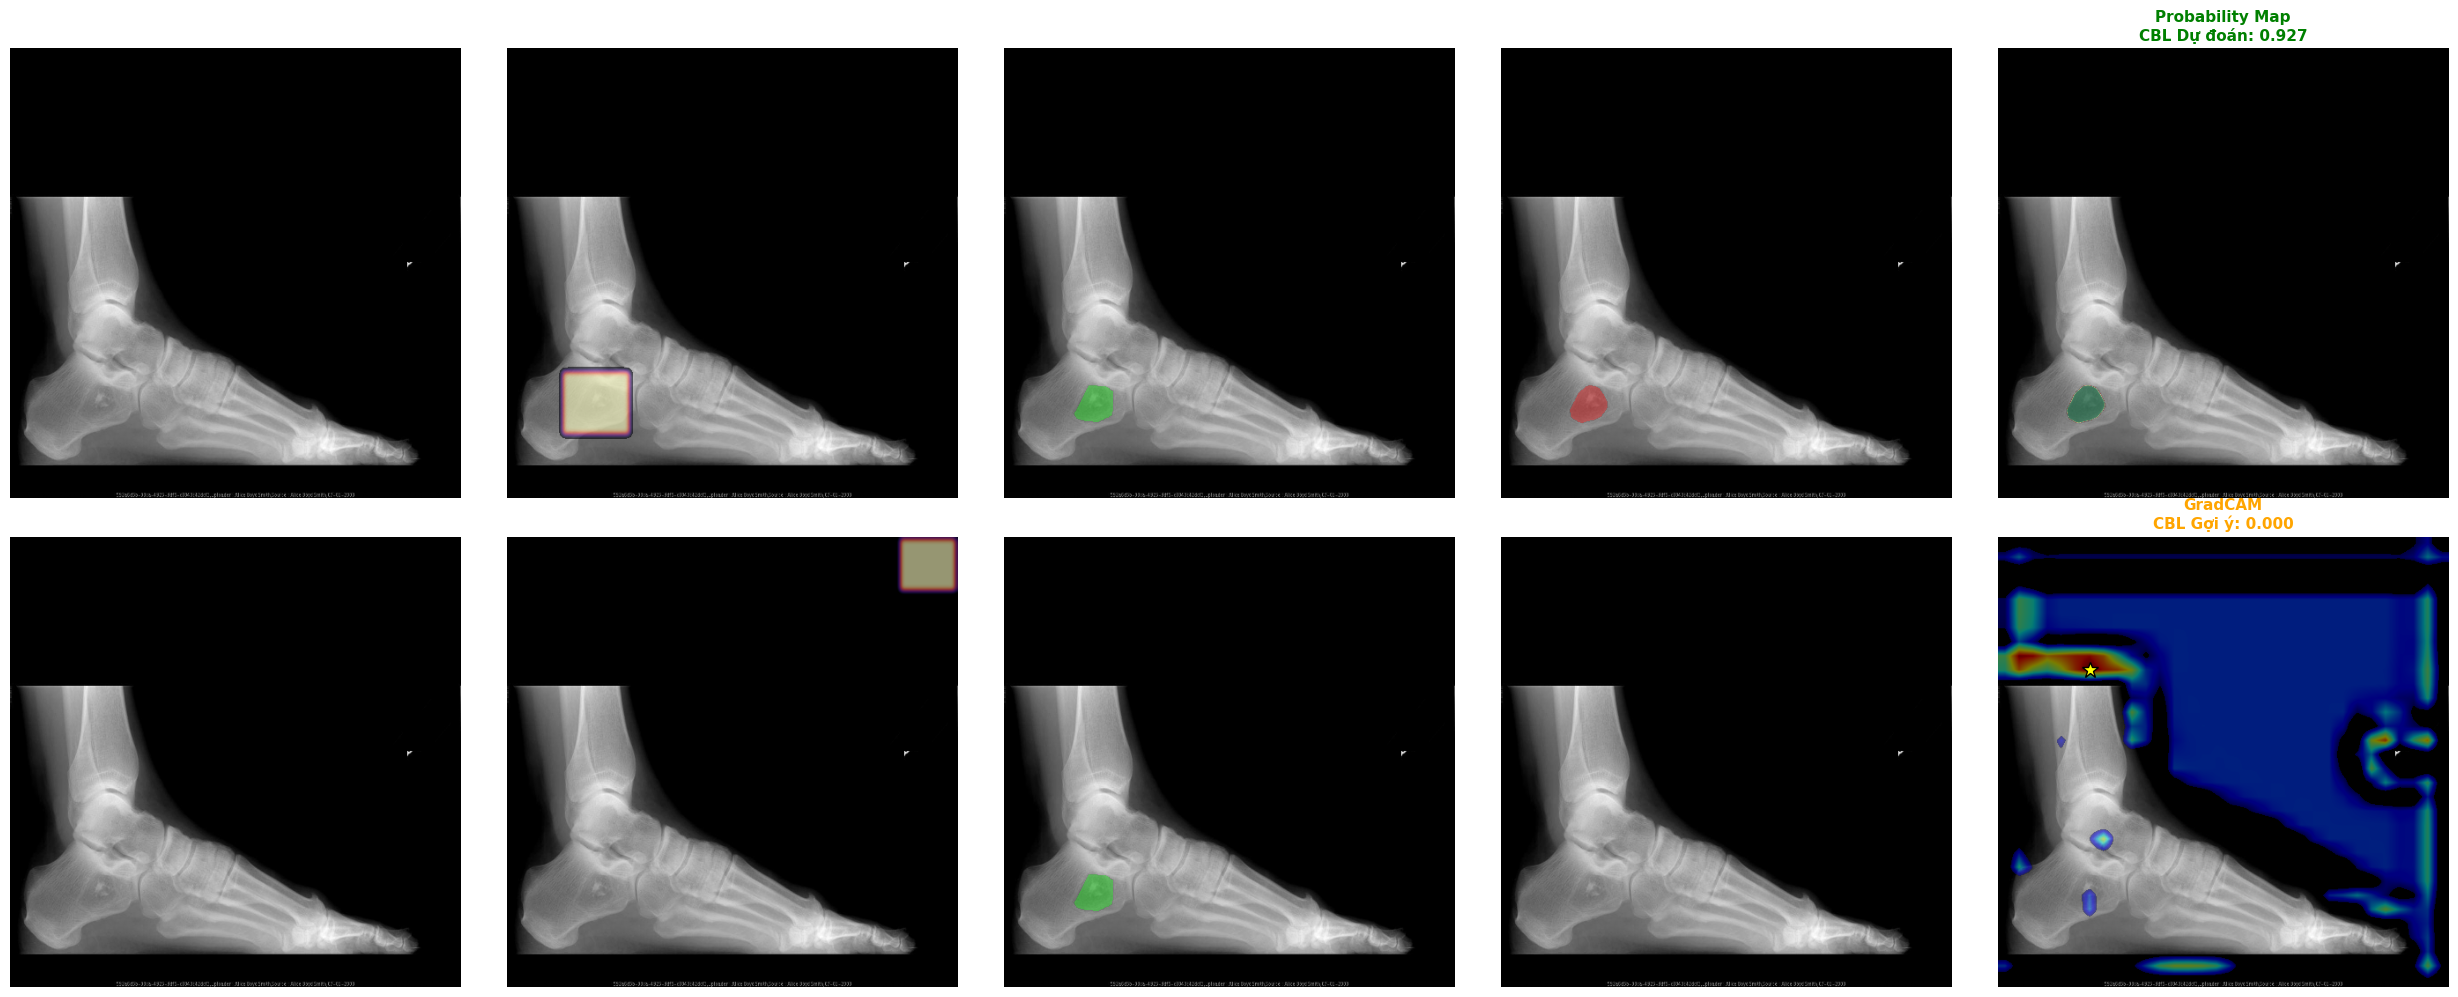

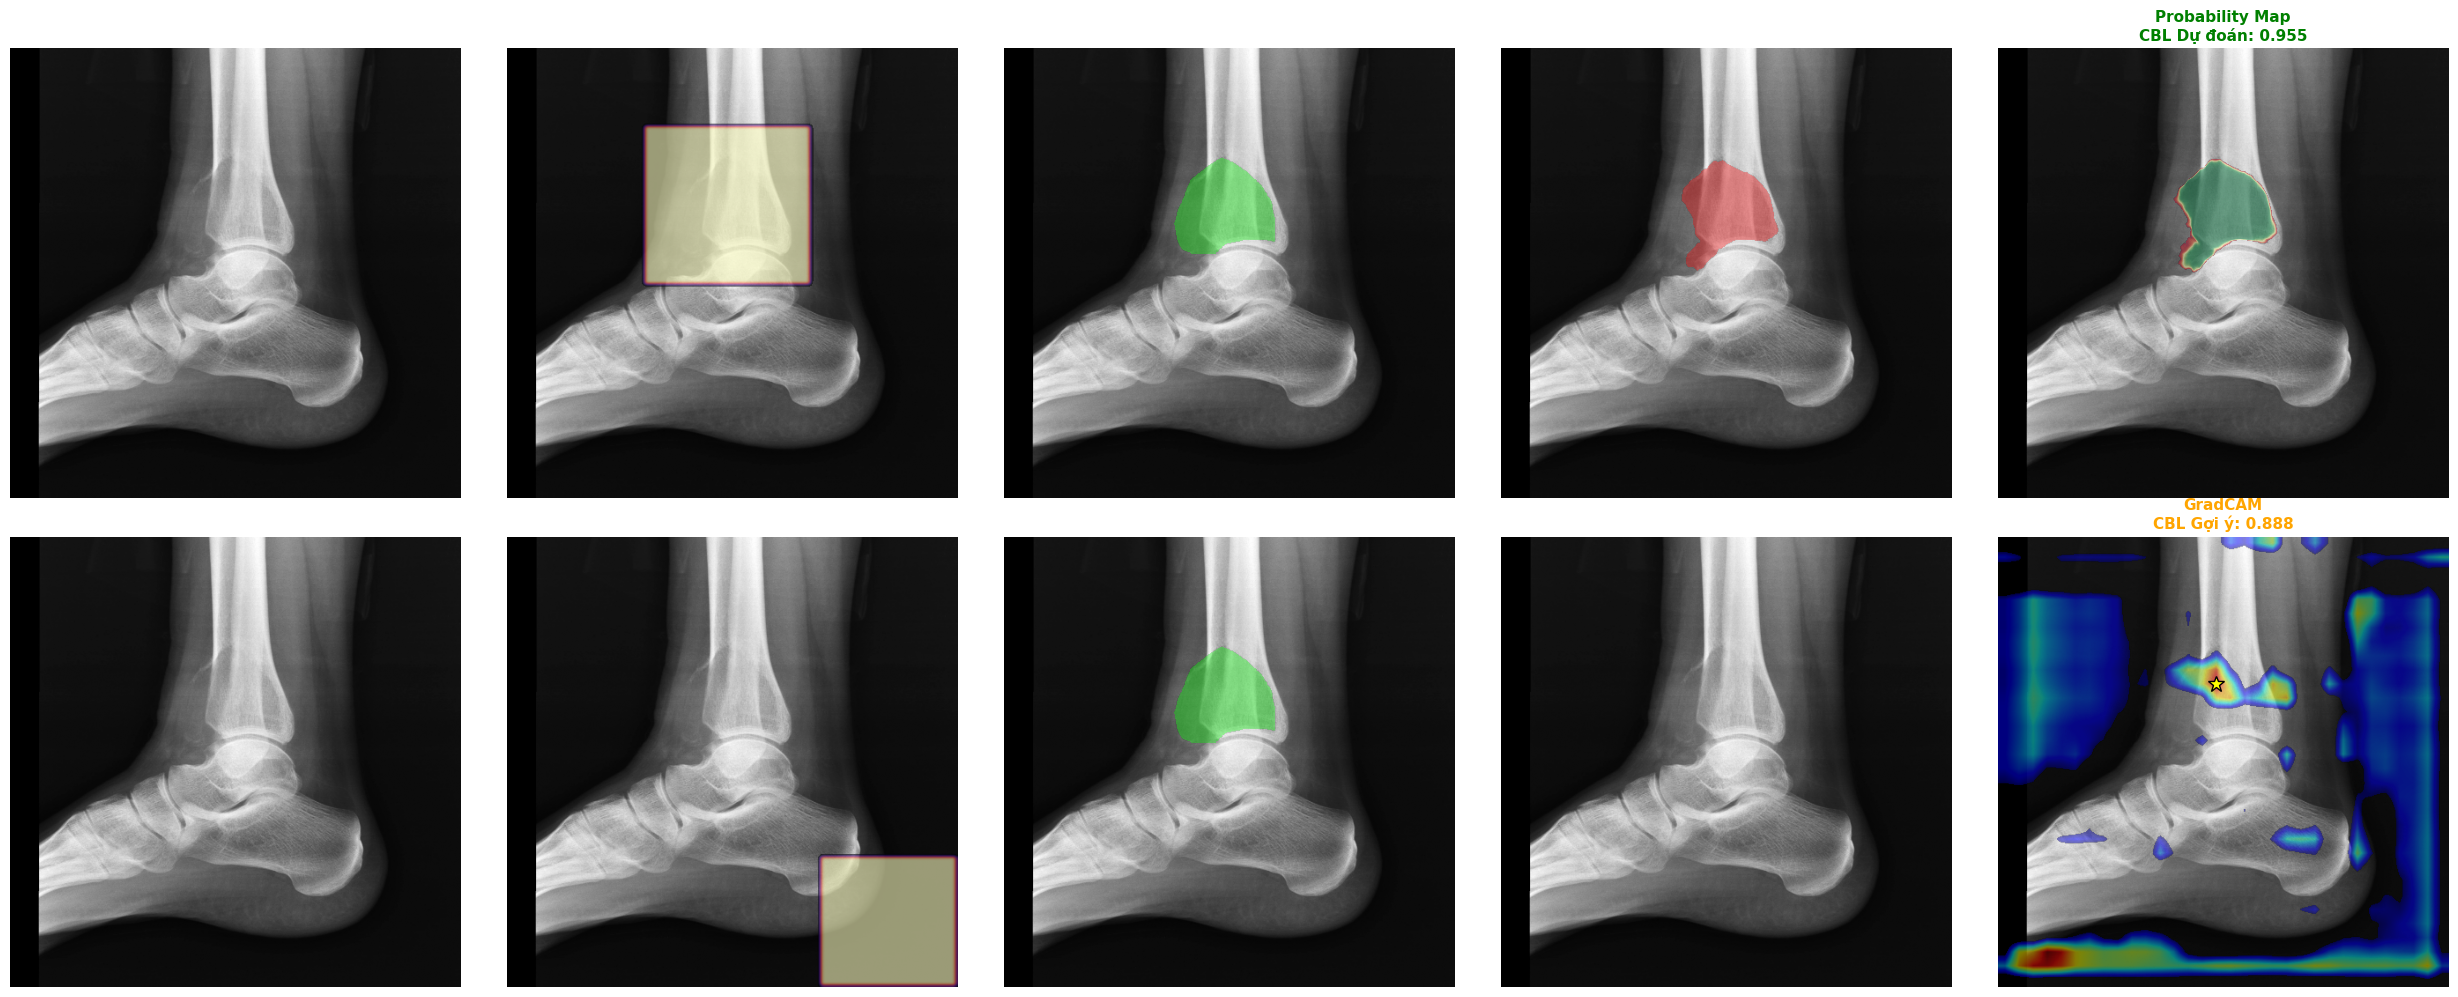

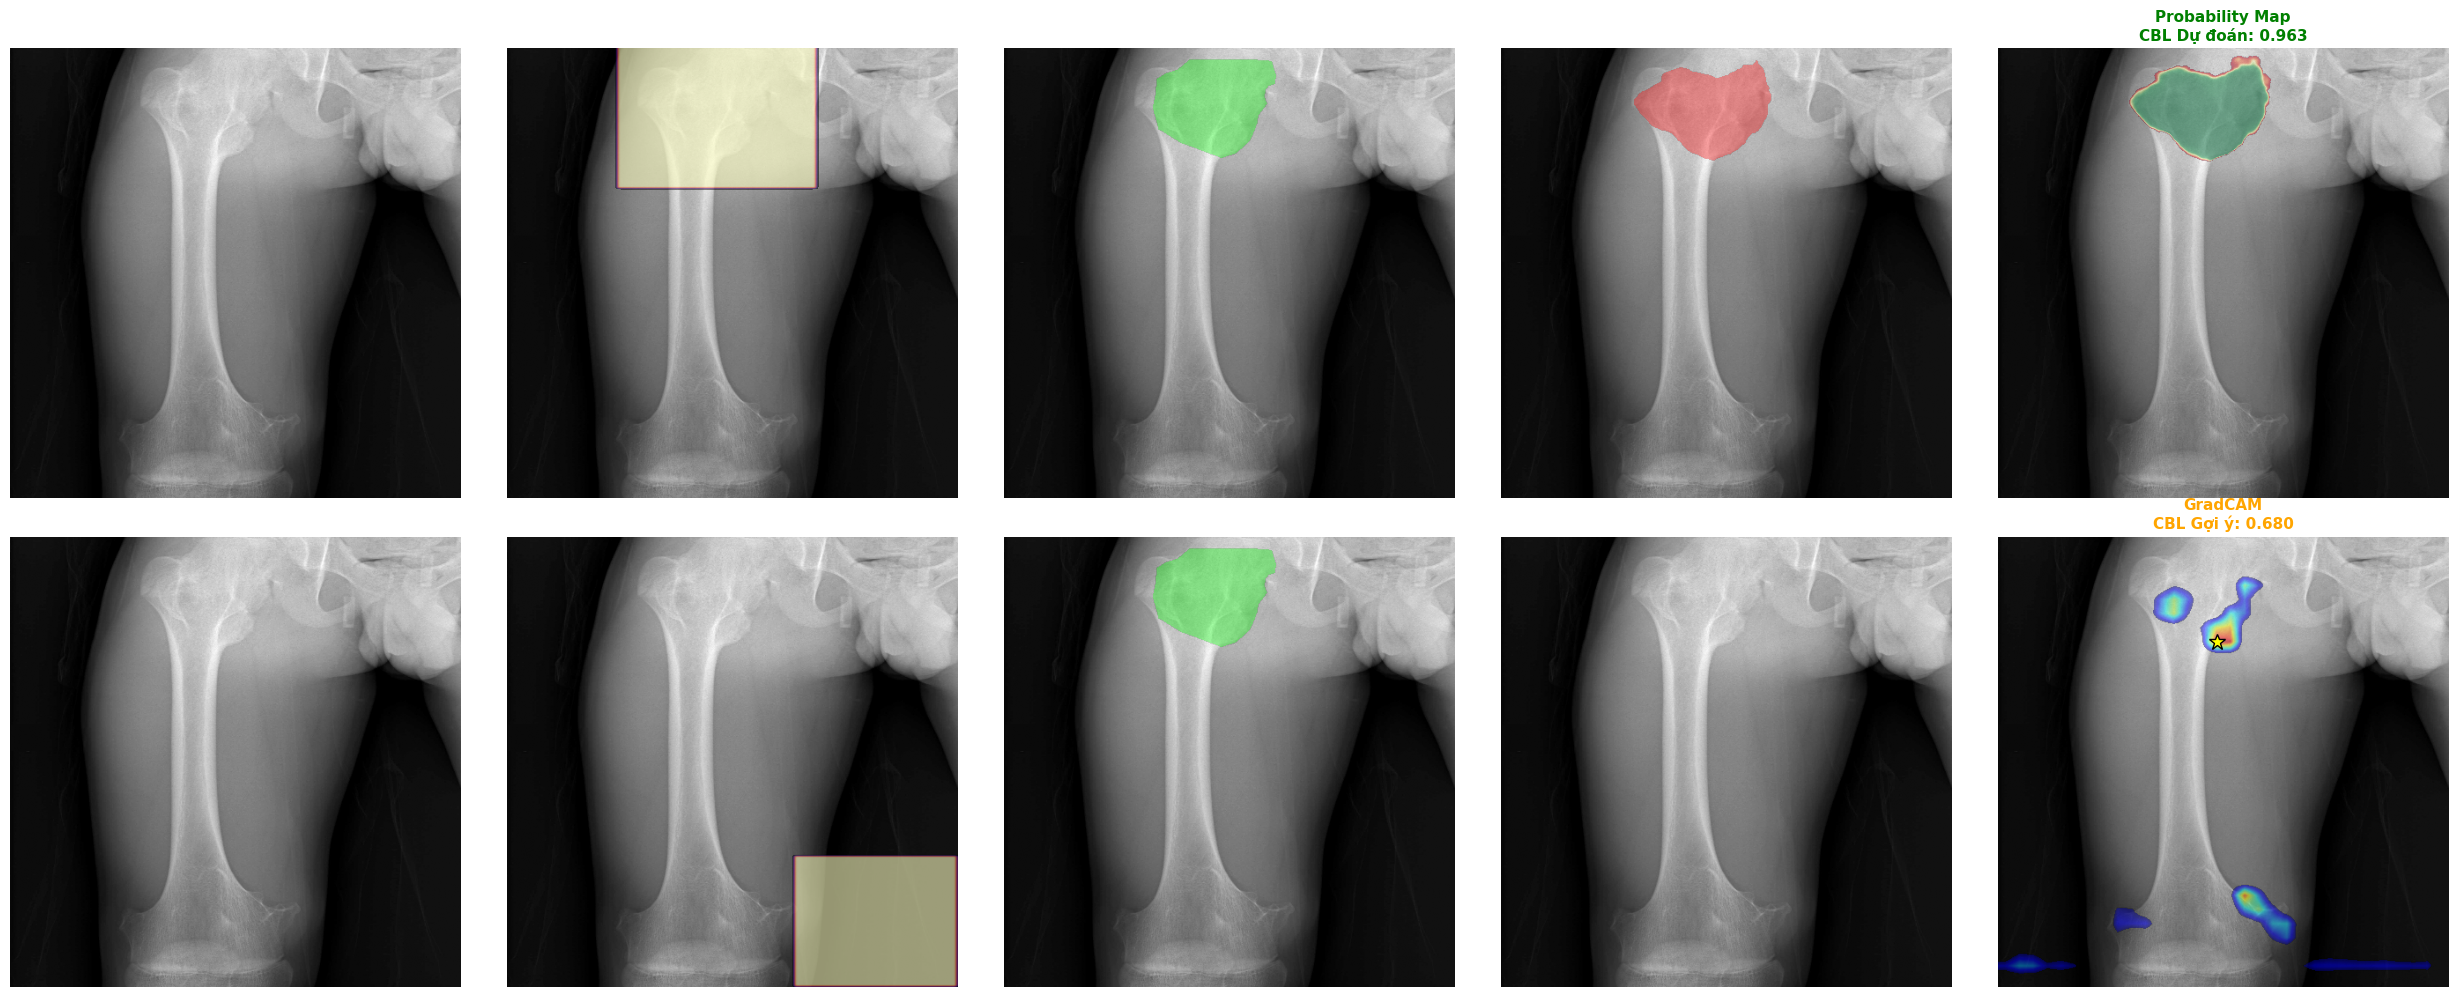

In [ ]:
# @title
import os
import cv2
import json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# CẤU HÌNH HỆ THỐNG
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
USE_ENCODER_PROMPT = True

# Các chốt chặn an toàn
CONFIDENCE_THRESHOLD = 0.80
CENTER_DIST_RATIO    = 0.25
DARK_PIXEL_THRESHOLD = -0.80 # Điểm ảnh có cường độ < -0.80 (gần đen tuyệt đối)
DARK_RATIO_LIMIT     = 0.70  # Prompt chứa > 70% vùng đen -> Kích hoạt phòng vệ

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"
VIS_IMAGES     = ["IMG001768.png", "IMG001538.png", "IMG001100.png"]

# =========================================================
# HELPERS
# =========================================================
def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map)
    return float(xs.mean()), float(ys.mean())

def calc_cbl_point(px: float, py: float, gt_bin: np.ndarray):
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + 1e-6
    cx_gt, cy_gt = float(xs.mean()), float(ys.mean())
    d = np.sqrt((px - cx_gt) ** 2 + (py - cy_gt) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def compute_gradcam(model, image_tensor):
    gradients, activations = [], []
    def fwd_hook(module, inp, out):
        activations.append(out)
        out.register_hook(lambda g: gradients.append(g))

    hook = model.center.register_forward_hook(fwd_hook)
    model.eval()
    img_t = image_tensor.clone().detach().to(DEVICE)
    zero_prompt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = model(img_t, zero_prompt)
    model.zero_grad()
    out.sum().backward()
    hook.remove()
    if not gradients: return None
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# =========================================================
# LÕI KIỂM DUYỆT (Đã fix logic Dark BG và xóa Print Debug)
# =========================================================
def predict_with_check(model, img_tensor, prompt_tensor):
    model.eval()

    with torch.no_grad():
        out  = model(img_tensor.to(DEVICE), prompt_tensor.to(DEVICE))
        prob = torch.sigmoid(out)
        pred = (prob > 0.5).float()

    conf     = prob.max().item()
    pm_np    = prompt_tensor[0, 0].numpy()
    pr_np    = pred[0, 0].cpu().numpy()
    img_np   = img_tensor[0, 0].numpy()
    prob_np  = prob[0, 0].cpu().numpy()

    ys_p, xs_p = np.where(pm_np > 0.3)
    cx_pmt = xs_p.mean() if len(xs_p) > 0 else IMG_SIZE / 2
    cy_pmt = ys_p.mean() if len(ys_p) > 0 else IMG_SIZE / 2
    prompt_area = len(xs_p)

    cx_pr, cy_pr = get_centroid(pr_np)
    pred_area    = int(pr_np.sum())

    dist_pred_pmt = (np.sqrt((cx_pr - cx_pmt)**2 + (cy_pr - cy_pmt)**2)
                     if cx_pr is not None else IMG_SIZE)

    # --- BỘ QUY TẮC AN TOÀN ---
    suspicious_conf = conf < CONFIDENCE_THRESHOLD
    suspicious_dist = dist_pred_pmt > (IMG_SIZE * CENTER_DIST_RATIO)
    suspicious_area = pred_area < 50

    suspicious_ratio = False
    if prompt_area > 0 and (pred_area / float(prompt_area)) < 0.05:
        suspicious_ratio = True

    # Đo lường tỷ lệ nền đen (Tiêu chí 100% win)
    prompt_mask = pm_np > 0.3
    if prompt_mask.sum() > 0:
        dark_pixels = (img_np[prompt_mask] < DARK_PIXEL_THRESHOLD).sum()
        dark_ratio  = dark_pixels / prompt_mask.sum()
        suspicious_dark_bg = dark_ratio > DARK_RATIO_LIMIT
    else:
        suspicious_dark_bg = True
        dark_ratio = 1.0

    reasons = {
        "LOW_CONF"    : suspicious_conf,
        "FAR_DIST"    : suspicious_dist,
        "TINY_AREA"   : suspicious_area,
        "TINY_RATIO"  : suspicious_ratio,
        "DARK_BG_70%" : suspicious_dark_bg
    }

    is_suspicious = any(reasons.values())

    if is_suspicious:
        pr_np = np.zeros_like(pr_np)
        cx_pr = cy_pr = None
        sal_out = compute_gradcam(model, img_tensor) # Kích hoạt GradCAM cứu hộ
    else:
        sal_out = None

    return dict(mask=pr_np, prob_map=prob_np, confidence=conf,
                center_dist=dist_pred_pmt, cx_pred=cx_pr, cy_pred=cy_pr,
                is_suspicious=is_suspicious, saliency=sal_out, dark_ratio=dark_ratio)

# =========================================================
# THỐNG KÊ ĐỘ CHÍNH XÁC GRADCAM TRÊN TẬP 174 CA LỖI
# =========================================================
def evaluate_gradcam_rescue_stats(model):
    print("\n" + "="*70)
    print("📊 ĐÁNH GIÁ CHẤT LƯỢNG GỢI Ý CỨU HỘ GRADCAM (CHỈ TÍNH TRÊN CÁC CA BỊ BẮT LỖI)")
    print("="*70)

    test_ds = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    loader = DataLoader(test_ds, batch_size=1, shuffle=False)

    sugg_cbl_list = []
    eligible_samples = 0

    model.eval()
    for img_t, mask_t, _ in tqdm(loader, desc="Đang quét tìm vùng đen & đánh giá"):
        img_np = img_t[0,0].numpy()
        gt_np = mask_t[0, 0].numpy()
        if gt_np.sum() == 0: continue

        # 1. Quét tìm vùng có nền đen nhất trên ảnh
        box_w, box_h = 80, 80
        best_dark_ratio = -1
        corners = [
            (10, 10), (IMG_SIZE-box_w-10, 10),
            (10, IMG_SIZE-box_h-10), (IMG_SIZE-box_w-10, IMG_SIZE-box_h-10),
            (IMG_SIZE//2, 10), (10, IMG_SIZE//2)
        ]
        for (x, y) in corners:
            roi = img_np[y:y+box_h, x:x+box_w]
            ratio = (roi < DARK_PIXEL_THRESHOLD).sum() / (box_w * box_h)
            if ratio > best_dark_ratio:
                best_dark_ratio = ratio

        # 2. CHỈ đưa vào thống kê nếu ảnh này có vùng nền đủ đen (> 70%)
        # (tương ứng với 174 ca kích hoạt thành công GradCAM)
        if best_dark_ratio < DARK_RATIO_LIMIT:
            continue

        eligible_samples += 1

        # 3. Kích hoạt GradCAM và tìm điểm Peak
        sal = compute_gradcam(model, img_t)
        if sal is None: continue

        peak_y, peak_x = np.unravel_index(sal.argmax(), sal.shape)

        # 4. Tính toán độ chuẩn xác CBL của điểm cứu hộ so với nhãn gốc
        cbl_val = calc_cbl_point(peak_x, peak_y, gt_np)
        if cbl_val is not None:
            sugg_cbl_list.append(cbl_val)

    # --- TÍNH TOÁN THỐNG KÊ ---
    if not sugg_cbl_list:
        print("Không tìm thấy mẫu nào hợp lệ.")
        return

    cbl_arr = np.array(sugg_cbl_list)
    avg_cbl = np.mean(cbl_arr)
    max_cbl = np.max(cbl_arr)
    min_cbl = np.min(cbl_arr)

    group_1 = np.sum((cbl_arr >= 0.0) & (cbl_arr < 0.5))
    group_2 = np.sum((cbl_arr >= 0.5) & (cbl_arr < 0.7))
    group_3 = np.sum((cbl_arr >= 0.7) & (cbl_arr < 0.9))
    group_4 = np.sum((cbl_arr >= 0.9) & (cbl_arr <= 1.0))
    total = len(cbl_arr)

    print(f"\nKết quả thống kê trên {total}/{eligible_samples} mẫu kích hoạt cứu hộ:")
    print(f"  - CBL Trung bình: {avg_cbl:.4f}")
    print(f"  - CBL Cao nhất:   {max_cbl:.4f} (Gợi ý cực chuẩn)")
    print(f"  - CBL Thấp nhất:  {min_cbl:.4f} (Gợi ý bị lệch)")

    print("\nPhân bổ độ chính xác gợi ý cứu hộ:")
    print(f"  [0.0 - 0.5): {group_1:3d} mẫu ({group_1/total*100:5.1f}%) ➔ Yếu (Gợi ý sai vùng)")
    print(f"  [0.5 - 0.7): {group_2:3d} mẫu ({group_2/total*100:5.1f}%) ➔ Trung bình (Cần IPR nắn nhiều)")
    print(f"  [0.7 - 0.9): {group_3:3d} mẫu ({group_3/total*100:5.1f}%) ➔ Tốt (Bám sát khối u)")
    print(f"  [0.9 - 1.0]: {group_4:3d} mẫu ({group_4/total*100:5.1f}%) ➔ Xuất sắc (Trúng tâm)")
    print("="*70)

# =========================================================
# VISUALIZE
# =========================================================
def visualize_inference_check(model, img_name):
    img_path = os.path.join(TEST_IMAGE_DIR, img_name)
    json_path = os.path.join(TEST_JSON_DIR, os.path.splitext(img_name)[0] + '.json')
    if not os.path.exists(img_path): return

    image_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    orig_h, orig_w = image_cv.shape

    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    target_shape = next((s for s in data.get('shapes', []) if s.get('shape_type') == 'polygon' and len(s.get('points', [])) > 2), data['shapes'][0])
    points = np.array(target_shape['points'])
    x_min, y_min = np.min(points, axis=0)
    x_max, y_max = np.max(points, axis=0)
    gt_w, gt_h = x_max - x_min, y_max - y_min

    mask_cv = np.zeros((orig_h, orig_w), dtype=np.uint8)
    cv2.fillPoly(mask_cv, [points.astype(np.int32)], 255)

    ds_h = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    r = (ds_h.zoom_ratio[0] + ds_h.zoom_ratio[1]) / 2

    def make_prompt(bx0, bx1, by0, by1):
        pm = ds_h.create_plateau_heatmap([bx0, by0, bx1, by1], orig_h, orig_w)
        pmr = cv2.resize(pm, (IMG_SIZE, IMG_SIZE))
        return pmr, torch.from_numpy(pmr).unsqueeze(0).unsqueeze(0)

    pm_good_np, pm_good_t = make_prompt(x_min - gt_w*r, x_max + gt_w*r, y_min - gt_h*r, y_max + gt_h*r)
    fx = orig_w - gt_w*(1+r)-10 if x_min < orig_w//2 else 10
    fy = orig_h - gt_h*(1+r)-10 if y_min < orig_h//2 else 10
    pm_bad_np, pm_bad_t = make_prompt(fx, fx+gt_w*(1+r), fy, fy+gt_h*(1+r))

    image_r = cv2.resize(image_cv, (IMG_SIZE, IMG_SIZE))
    mask_r = (cv2.resize(mask_cv, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)
    img_t = torch.from_numpy((image_r.astype(np.float32)/255.0-0.5)/0.5).unsqueeze(0).unsqueeze(0)

    res_good = predict_with_check(model, img_t, pm_good_t)
    res_bad = predict_with_check(model, img_t, pm_bad_t)

    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    for row, (label, res, pm_np, color) in enumerate([('Prompt ĐÚNG', res_good, pm_good_np, 'green'), ('Prompt SAI', res_bad, pm_bad_np, 'red')]):
        img_np = image_r / 255.0

        axes[row][0].imshow(img_np, cmap='gray')
        axes[row][0].set_ylabel(f"{label}", color=color, fontweight='bold', rotation=0, labelpad=50, va='center')

        axes[row][1].imshow(img_np, cmap='gray')
        axes[row][1].imshow(np.ma.masked_where(pm_np < 0.05, pm_np), cmap='magma', alpha=0.6)

        green_overlay = np.zeros((*mask_r.shape, 4)); green_overlay[mask_r == 1] = [0, 1, 0, 0.35]
        axes[row][2].imshow(img_np, cmap='gray'); axes[row][2].imshow(green_overlay)

        red_overlay = np.zeros((*res['mask'].shape, 4)); red_overlay[res['mask'] == 1] = [1, 0, 0, 0.35]
        axes[row][3].imshow(img_np, cmap='gray'); axes[row][3].imshow(red_overlay)

        axes[row][4].imshow(img_np, cmap='gray')

        if res['saliency'] is not None:
            axes[row][4].imshow(np.ma.masked_where(res['saliency'] < 0.2, res['saliency']), cmap='jet', alpha=0.5)
            py, px = np.unravel_index(res['saliency'].argmax(), res['saliency'].shape)
            axes[row][4].plot(px, py, '*', color='yellow', ms=12, markeredgecolor='black')
            cbl_val = calc_cbl_point(px, py, mask_r)
            axes[row][4].set_title(f"GradCAM\nCBL Gợi ý: {cbl_val:.3f}" if cbl_val is not None else "GradCAM", fontsize=11, fontweight='bold', color='orange')
        else:
            axes[row][4].imshow(np.ma.masked_where(res['prob_map'] < 0.1, res['prob_map']), cmap='RdYlGn', alpha=0.5)
            if res['cx_pred'] is not None and res['cy_pred'] is not None:
                cbl_val = calc_cbl_point(res['cx_pred'], res['cy_pred'], mask_r)
                cbl_str = f"CBL Dự đoán: {cbl_val:.3f}" if cbl_val is not None else "CBL: N/A"
            else:
                cbl_str = "CBL: N/A (Mask rỗng)"
            axes[row][4].set_title(f"Probability Map\n{cbl_str}", fontsize=11, fontweight='bold', color='green')

        for ax in axes[row]: ax.axis('off')

    plt.tight_layout()
    plt.show()

# =========================================================
# CHẠY CHƯƠNG TRÌNH
# =========================================================
if __name__ == "__main__":
    model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))

    # 1. Chạy đánh giá GradCAM với đúng 174 mẫu hợp lệ
    evaluate_gradcam_rescue_stats(model)

    # 2. Hiển thị ảnh trực quan
    for img_name in VIS_IMAGES:
        visualize_inference_check(model, img_name)

🔍 Đang quét 174 mẫu vùng nền đen với 5 vòng lặp IPR...



————————————————————————— TRỰC QUAN HÓA 5 VÒNG IPR —————————————————————————


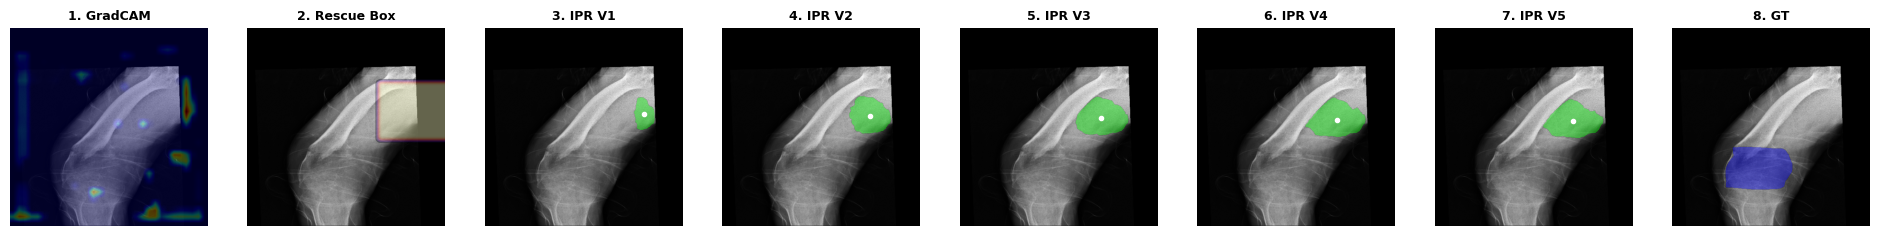

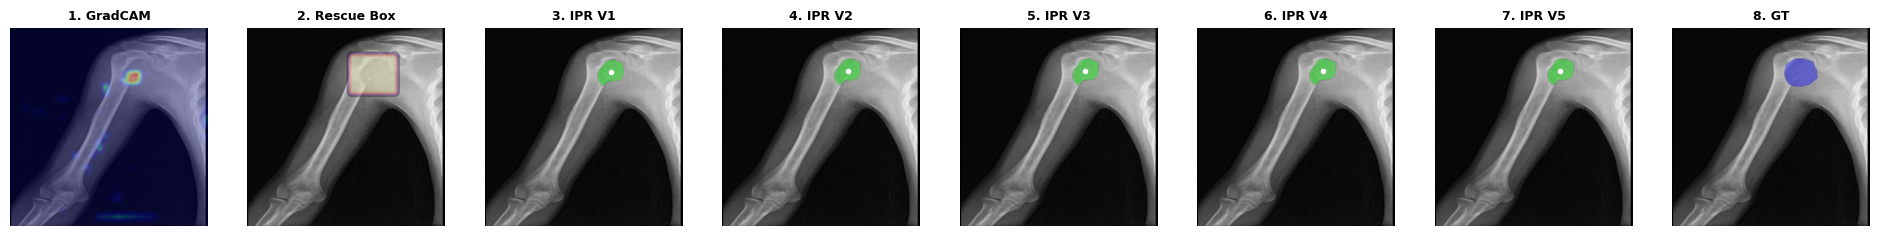

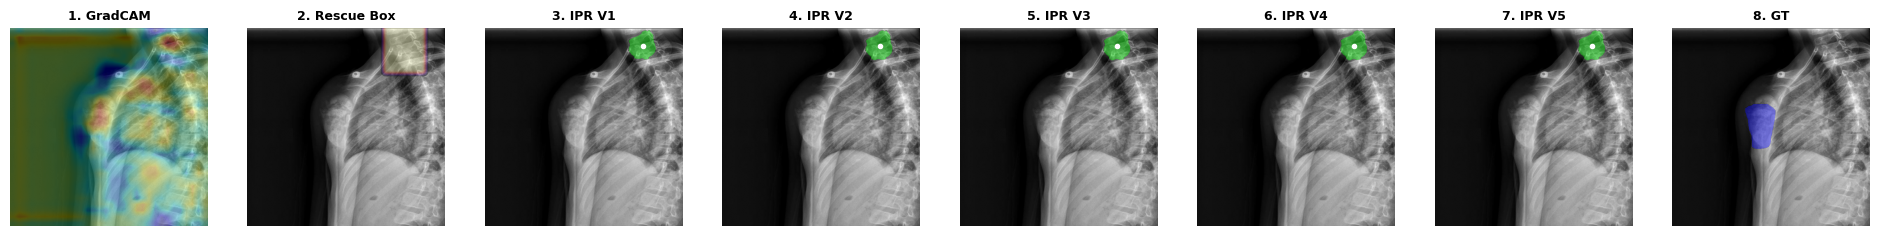

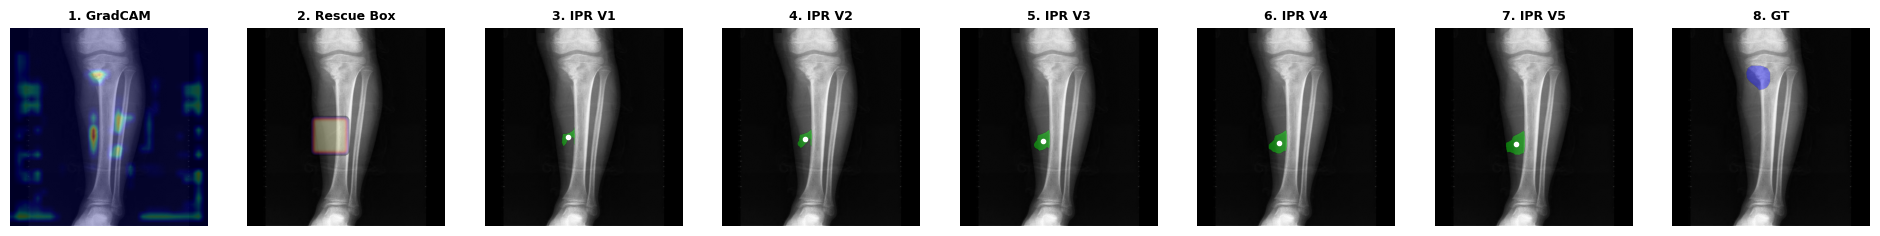

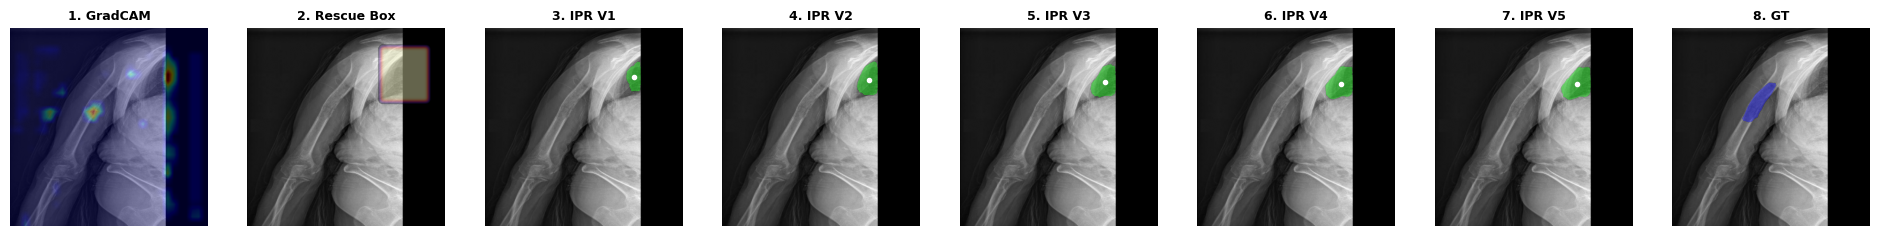

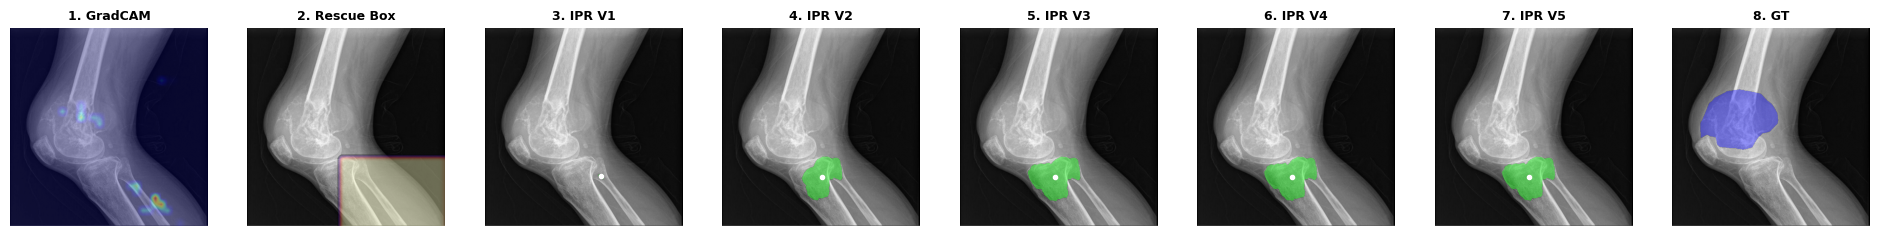

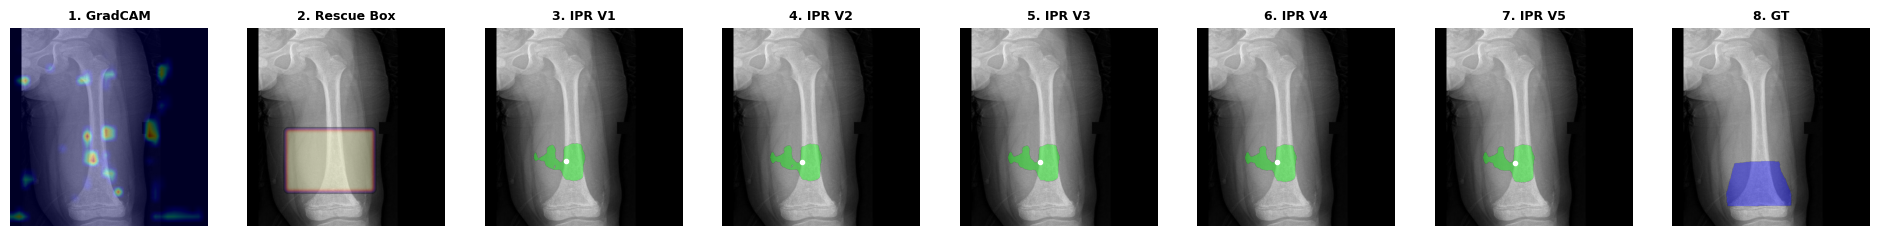

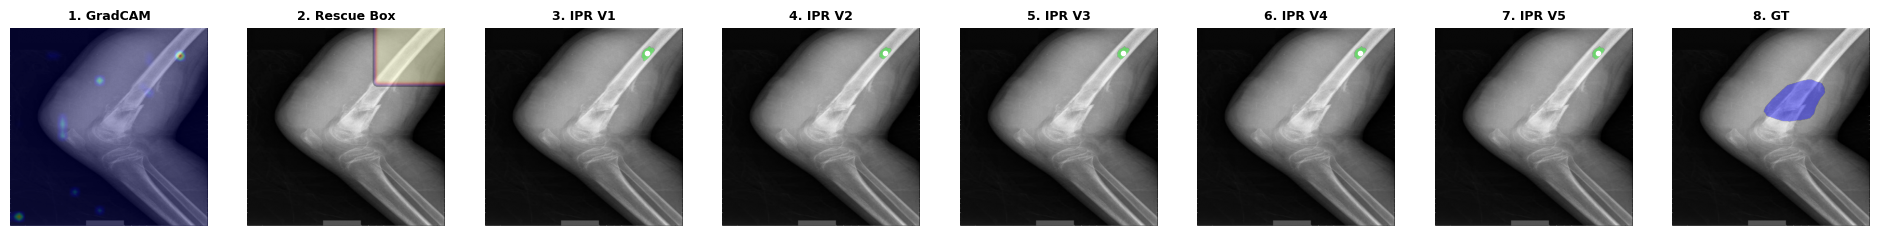

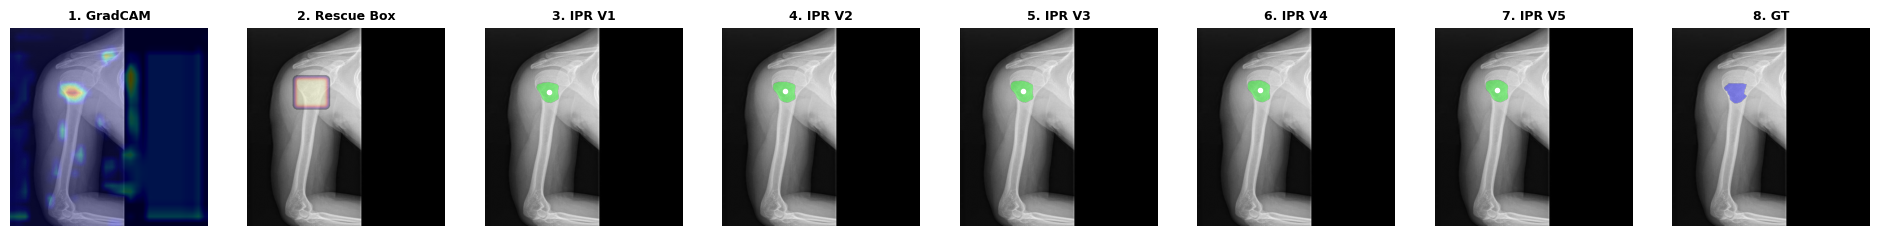

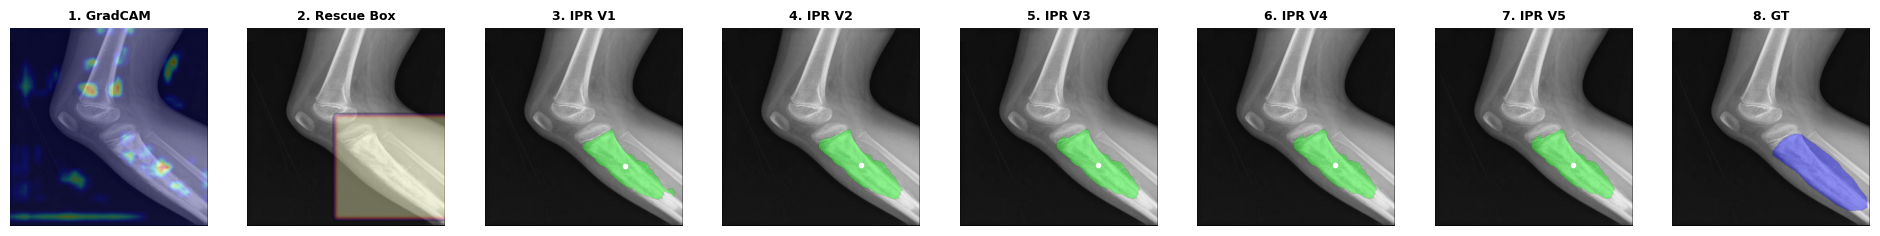


Giai đoạn    |    Dice↑ |     IoU↑ |     CBL↑
--------------------------------------------------
Vòng 1       |   0.2516 |   0.2046 |   0.3268
Vòng 2       |   0.2840 |   0.2415 |   0.3443
Vòng 3       |   0.2956 |   0.2558 |   0.3510
Vòng 4       |   0.2988 |   0.2602 |   0.3543
Vòng 5       |   0.2997 |   0.2618 |   0.3556


In [ ]:
# @title
import os
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

from dataset import BTXRD_Dataset
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# 1. CẤU HÌNH (THAY ĐỔI TẠI ĐÂY)
# =========================================================
DEVICE             = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH         = "checkpoints/pga_unet_expB_best.pth"
IMG_SIZE           = 512
USE_ENCODER_PROMPT = True

# --- THÔNG SỐ IPR ---
NUM_IPR_STEPS      = 5       # <--- BIẾN KHAI BÁO SỐ VÒNG LẶP THEO Ý MUỐN
NUM_VISUALIZE      = 10       # Số lượng ảnh muốn hiển thị mẫu

# --- THÔNG SỐ PHÒNG VỆ ---
DARK_PIXEL_THRESHOLD = -0.80
DARK_RATIO_LIMIT     = 0.70

TEST_IMAGE_DIR = "dataset_BTXRD/test/images"
TEST_JSON_DIR  = "dataset_BTXRD/test/annotations"

# =========================================================
# 2. HELPERS (METRICS, GRADCAM, CENTROID)
# =========================================================
def extract_lcc(binary_map: np.ndarray) -> np.ndarray:
    if binary_map.sum() == 0: return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1: return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def calc_metrics(pm, gm):
    pm, gm = (pm > 0.5).astype(np.float32), (gm > 0.5).astype(np.float32)
    tp = (pm * gm).sum()
    fp = (pm * (1 - gm)).sum()
    fn = ((1 - pm) * gm).sum()
    dice = (2 * tp + 1e-5) / (2 * tp + fp + fn + 1e-5)
    iou = (tp + 1e-5) / (tp + fp + fn + 1e-5)
    return dice, iou

def calc_cbl(pred_bin: np.ndarray, gt_bin: np.ndarray):
    if gt_bin.sum() == 0 or pred_bin.sum() == 0: return 0.0
    ys, xs = np.where(gt_bin); yp, xp = np.where(pred_bin)
    gt_diag = np.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + 1e-6
    d = np.sqrt((xp.mean() - xs.mean()) ** 2 + (yp.mean() - ys.mean()) ** 2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def compute_gradcam(model, image_tensor):
    gradients, activations = [], []
    def fwd_hook(module, inp, out):
        activations.append(out)
        out.register_hook(lambda g: gradients.append(g))
    hook = model.center.register_forward_hook(fwd_hook)
    model.eval()
    img_t = image_tensor.clone().detach().to(DEVICE)
    zero_prompt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out = model(img_t, zero_prompt)
    model.zero_grad()
    out.sum().backward()
    hook.remove()
    if not gradients: return None
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def get_centroid(binary_map: np.ndarray):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map > 0.5)
    return float(xs.mean()), float(ys.mean())

# =========================================================
# 3. CHƯƠNG TRÌNH ĐÁNH GIÁ TỰ ĐỘNG
# =========================================================
def run_dynamic_ipr_evaluation(model):
    test_ds = BTXRD_Dataset(TEST_IMAGE_DIR, TEST_JSON_DIR, img_size=IMG_SIZE, is_train=False)
    loader = DataLoader(test_ds, batch_size=1, shuffle=False)
    r = (test_ds.zoom_ratio[0] + test_ds.zoom_ratio[1]) / 2

    # Khởi tạo stats dựa trên biến NUM_IPR_STEPS
    stats = {f'Vòng {v}': {'dice': [], 'iou': [], 'cbl': []} for v in range(1, NUM_IPR_STEPS + 1)}
    vis_data = []

    print(f"🔍 Đang quét 174 mẫu vùng nền đen với {NUM_IPR_STEPS} vòng lặp IPR...")

    model.eval()
    for i, (img_t, mask_t, _) in enumerate(tqdm(loader, leave=False)):
        img_np, gt_np = img_t[0,0].numpy(), mask_t[0, 0].numpy()
        if gt_np.sum() == 0: continue

        # Logic lọc vùng nền đen (Dark Background Check)
        box_w, box_h = 80, 80
        best_dark_ratio = -1
        corners = [(10, 10), (IMG_SIZE-box_w-10, 10), (10, IMG_SIZE-box_h-10), (IMG_SIZE-box_w-10, IMG_SIZE-box_h-10)]
        for (bx, by) in corners:
            roi = img_np[by:by+box_h, bx:bx+box_w]
            ratio = (roi < DARK_PIXEL_THRESHOLD).sum() / (box_w * box_h)
            best_dark_ratio = max(best_dark_ratio, ratio)

        if best_dark_ratio < DARK_RATIO_LIMIT: continue

        # --- BẮT ĐẦU CỨU HỘ ---
        img_t = img_t.to(DEVICE)
        sal = compute_gradcam(model, img_t)
        py_curr, px_curr = np.unravel_index(sal.argmax(), sal.shape)

        ys_g, xs_g = np.where(gt_np)
        gt_w, gt_h = xs_g.max()-xs_g.min(), ys_g.max()-ys_g.min()
        bw, bh = gt_w*(1+r), gt_h*(1+r)

        temp_vis = {'sal': sal, 'steps': [], 'gt': gt_np, 'img': img_np}

        # --- CHUỖI LẶP IPR DỰA TRÊN BIẾN KHAI BÁO ---
        for v in range(1, NUM_IPR_STEPS + 1):
            pm = test_ds.create_plateau_heatmap([px_curr-bw/2, py_curr-bh/2, px_curr+bw/2, py_curr+bh/2], IMG_SIZE, IMG_SIZE)
            pm_t = torch.from_numpy(cv2.resize(pm, (IMG_SIZE, IMG_SIZE))).unsqueeze(0).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                prob = torch.sigmoid(model(img_t, pm_t))[0,0].cpu().numpy()
                mask = extract_lcc((prob > 0.5).astype(np.float32))

                # Tính toán Metrics
                dice, iou = calc_metrics(mask, gt_np)
                cbl = calc_cbl(mask, gt_np)

                stats[f'Vòng {v}']['dice'].append(dice)
                stats[f'Vòng {v}']['iou'].append(iou)
                stats[f'Vòng {v}']['cbl'].append(cbl)

                # Cập nhật tâm cho vòng sau (Feedback loop)
                cx, cy = get_centroid(mask)
                if cx is not None:
                    px_curr, py_curr = cx, cy

                # Lưu dữ liệu để vẽ (chỉ lưu cho số lượng ảnh giới hạn)
                if len(vis_data) < NUM_VISUALIZE:
                    temp_vis['steps'].append({'mask': mask, 'cx': cx, 'cy': cy, 'pm': pm})

        if len(vis_data) < NUM_VISUALIZE: vis_data.append(temp_vis)

    # --- HIỂN THỊ HÌNH ẢNH (Dòng chảy IPR) ---
    print("\n" + "—"*25 + f" TRỰC QUAN HÓA {NUM_IPR_STEPS} VÒNG IPR " + "—"*25)
    for data in vis_data:
        # Số lượng cột = 1 (GradCAM) + 1 (Rescue Box) + NUM_IPR_STEPS + 1 (GT)
        num_cols = 3 + NUM_IPR_STEPS
        fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 3, 3))
        img_disp = data['img'] * 0.5 + 0.5

        # 1. GradCAM
        axes[0].imshow(img_disp, cmap='gray'); axes[0].imshow(data['sal'], cmap='jet', alpha=0.3)
        axes[0].set_title("1. GradCAM", fontsize=9, fontweight='bold'); axes[0].axis('off')

        # 2. Rescue Box
        axes[1].imshow(img_disp, cmap='gray'); axes[1].imshow(np.ma.masked_where(data['steps'][0]['pm']<0.1, data['steps'][0]['pm']), cmap='magma', alpha=0.4)
        axes[1].set_title("2. Rescue Box", fontsize=9, fontweight='bold'); axes[1].axis('off')

        # 3. Các vòng IPR
        for v in range(NUM_IPR_STEPS):
            ax = axes[v+2]; ax.imshow(img_disp, cmap='gray')
            mk = data['steps'][v]['mask']
            ov = np.zeros((*mk.shape, 4)); ov[mk > 0.5] = [0, 1, 0, 0.4]
            ax.imshow(ov)
            if data['steps'][v]['cx']:
                ax.plot(data['steps'][v]['cx'], data['steps'][v]['cy'], 'o', color='white', ms=3)
            ax.set_title(f"{v+3}. IPR V{v+1}", fontsize=9, fontweight='bold'); ax.axis('off')

        # 4. Ground Truth
        axes[-1].imshow(img_disp, cmap='gray')
        gt_ov = np.zeros((*data['gt'].shape, 4)); gt_ov[data['gt'] > 0.5] = [0, 0, 1, 0.4]
        axes[-1].imshow(gt_ov); axes[-1].set_title(f"{num_cols}. GT", fontsize=9, fontweight='bold'); axes[-1].axis('off')
        plt.show()

    # --- IN BẢNG THỐNG KÊ TỔNG HỢP ---
    print("\n" + "="*50)
    print(f"{'Giai đoạn':<12} | {'Dice↑':>8} | {'IoU↑':>8} | {'CBL↑':>8}")
    print("-" * 50)
    for v in range(1, NUM_IPR_STEPS + 1):
        k = f'Vòng {v}'
        if stats[k]['dice']:
            print(f"{k:<12} | {np.mean(stats[k]['dice']):>8.4f} | {np.mean(stats[k]['iou']):>8.4f} | {np.mean(stats[k]['cbl']):>8.4f}")
    print("="*50)

if __name__ == "__main__":
    model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    run_dynamic_ipr_evaluation(model)

In [ ]:
# =========================================================
# DOWNLOAD CHECKPOINT _ LOG
# =========================================================

!zip -r TN_B.zip checkpoints logs
from google.colab import files
files.download("TN_B.zip")

**Thử nghiệm chạy thực thi**

In [6]:
!pip install --upgrade huggingface_hub gradio
!pip install gradio
!pip install openpyxl torchmetrics -q, timm -q
%cd Prompt-Guided-XRay-Segmentation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: gradio-client
    Found existing installation: gradio_client 1.14.0
    Uninstalling gradio_client-1.14.0:
      Successfully uninstalled gradio_client-1.14.0
  Attempting uninstall: gradio
    Found existing installation: gradio 5.50.0
    Uninstalling gradio-5.50.0:
      Successfully uninstalled gradio-5.50.0

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [o

In [13]:
# @title
import warnings
warnings.filterwarnings("ignore")

import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import timm
from PIL import Image

# Nhập mô hình phân đoạn
from models.networks.prompt_unet_2D import PGA_UNet

# =========================================================
# 1. CẤU HÌNH & TẢI MÔ HÌNH CHUNG
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[*] HỆ THỐNG KHỞI CHẠY TRÊN THIẾT BỊ: {DEVICE}")

# --- Tải Mô Hình Sàng Lọc (MobileNetV4) ---
try:
    model_class = timm.create_model('mobilenetv4_hybrid_medium.ix_e550_r384_in1k', pretrained=False)
    in_features = model_class.classifier.in_features
    model_class.classifier = nn.Linear(in_features, 1)
    model_class = model_class.to(DEVICE)
    data_config = timm.data.resolve_model_data_config(model_class)
    class_transform = timm.data.create_transform(**data_config, is_training=False)
    model_class.load_state_dict(torch.load("checkpoints/best_mobilenetv4.pth", map_location=DEVICE))
    model_class.eval()
    print("[+] SÀNG LỌC: MobileNetV4 tải thành công!")
except Exception as e:
    print(f"[-] Lỗi tải MobileNetV4: {e}")

# --- Tải Mô Hình Phân Đoạn (PGA-UNet) ---
IMG_SIZE = 512
DARK_PIXEL_THRESHOLD = -0.80
DARK_RATIO_LIMIT = 0.70
NUM_IPR_STEPS = 3

model_prompt = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
try:
    model_prompt.load_state_dict(torch.load("checkpoints/pga_unet_expB_best.pth", map_location=DEVICE, weights_only=True))
    model_prompt.eval()
    print("[+] PHÂN ĐOẠN: PGA-UNet tải thành công!")
except Exception as e:
    print(f"[-] Lỗi tải PGA-UNet: {e}")

# =========================================================
# 2. HÀM XỬ LÝ (HELPERS)
# =========================================================
def extract_lcc(binary_map):
    if binary_map.sum() == 0: return binary_map
    mask_uint8 = binary_map.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1: return binary_map
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.float32)

def get_centroid(binary_map):
    if binary_map.sum() == 0: return None, None
    ys, xs = np.where(binary_map > 0.5)
    return float(xs.mean()), float(ys.mean())

def create_plateau_heatmap(bbox, orig_h, orig_w):
    heatmap = np.zeros((orig_h, orig_w), dtype=np.float32)
    pad = 5
    x_min, y_min = max(0, int(bbox[0])-pad), max(0, int(bbox[1])-pad)
    x_max, y_max = min(orig_w, int(bbox[2])+pad), min(orig_h, int(bbox[3])+pad)
    heatmap[y_min:y_max, x_min:x_max] = 1.0
    return cv2.GaussianBlur(heatmap, (31, 31), 0)

def compute_gradcam(model, img_tensor):
    gradients, activations = [], []
    def fwd_hook(module, inp, out):
        activations.append(out)
        out.register_hook(lambda g: gradients.append(g))
    hook = model.center.register_forward_hook(fwd_hook)
    model.eval()
    img_t = img_tensor.clone().detach().to(DEVICE)
    zero_prompt = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    try:
        out = model(img_t, zero_prompt)
        model.zero_grad()
        out.sum().backward()
    finally:
        hook.remove()
    if not gradients: return None
    w = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((w * activations[0]).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def overlay_clean_result(image_rgb, pred_mask, original_bbox, final_bbox=None, is_rescued=False):
    result = image_rgb.copy()
    colored = np.zeros_like(result)
    if pred_mask is not None and pred_mask.max() > 0:
        colored[pred_mask > 0] = [50, 220, 50] if is_rescued else [220, 50, 50]
        result = cv2.addWeighted(result, 1.0, colored, 0.5, 0)
    if is_rescued and final_bbox is not None:
        cv2.rectangle(result, (int(final_bbox[0]), int(final_bbox[1])), (int(final_bbox[2]), int(final_bbox[3])), (255, 215, 0), 2)
    if original_bbox is not None:
        cv2.rectangle(result, (int(original_bbox[0]), int(original_bbox[1])), (int(original_bbox[2]), int(original_bbox[3])), (180, 180, 180), 1)
    return result

# =========================================================
# 3. LOGIC XỬ LÝ SỰ KIỆN GIAO DIỆN
# =========================================================

# --- Logic Bước 1: Sàng Lọc ---
def run_classification(image):
    if image is None: return "❌ Vui lòng tải ảnh lên trước!"
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB) if len(image.shape) == 2 else image.copy()
    pil_img = Image.fromarray(image_rgb)
    input_tensor = class_transform(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model_class(input_tensor)
        prob = torch.sigmoid(output).item()
        pred_class = 1 if prob > 0.5 else 0
    ai_result = "CÓ BỆNH" if pred_class == 1 else "KHÔNG BỆNH"
    return f"🤖 AI Dự đoán: {ai_result} (Độ tin cậy: {prob if pred_class == 1 else 1 - prob:.3f})"

def confirm_nosick():
    html = """<div style='background-color: #d4edda; color: #155724; padding: 15px; border-radius: 5px; text-align: center; border: 1px solid #c3e6cb; font-size: 16px; font-weight: bold;'>
    ✅ Chúc mừng! Bệnh nhân khỏe mạnh, không phát hiện bệnh lý xương. Kết thúc quy trình.
    </div>"""
    return html, gr.update(visible=False)

def confirm_sick():
    html = """<div style='background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 5px; text-align: center; border: 1px solid #f5c6cb; font-size: 16px; font-weight: bold;'>
    ⚠️ Cảnh báo! Xác nhận CÓ BỆNH. Vui lòng chuyển đến bước định vị khối u.
    </div>"""
    return html, gr.update(visible=True)

# --- Logic Chuyển Màn Hình Siêu Tốc ---
def switch_to_segmentation(img):
    if img is None: return [gr.update()]*8
    clean_img = img.copy() # Lưu lại bản sạch để chạy AI
    return (
        gr.update(visible=False), # Ẩn Controls Sàng lọc
        gr.update(visible=False), # Ẩn Output Sàng lọc
        gr.update(visible=True),  # Hiện Controls Phân đoạn
        gr.update(visible=True),  # Hiện Output Phân đoạn
        clean_img,                # Cập nhật ảnh gốc sạch
        [],                       # Reset các điểm đã chấm
        "seg",                    # Cập nhật cờ trạng thái bước
        "Đang chờ khoanh Box..."  # Reset status box
    )

def switch_to_classification():
    return (
        gr.update(visible=True),   # Hiện Controls Sàng lọc
        gr.update(visible=True),   # Hiện Output Sàng lọc
        gr.update(visible=False),  # Ẩn Controls Phân đoạn
        gr.update(visible=False),  # Ẩn Output Phân đoạn
        None,                      # Xóa ảnh đầu vào
        None,                      # Xóa ảnh kết quả
        "cls",                     # Trở về trạng thái sàng lọc
        "Chờ dự đoán...",          # Reset Textbox
        "",                        # Xóa HTML thông báo
        gr.update(visible=False)   # Ẩn nút Chuyển tiếp
    )

# --- Logic Bước 2: Phân Đoạn ---
def get_clicks(img, evt: gr.SelectData, points_state, step):
    if step != "seg":
        return img, points_state, "Vui lòng hoàn thành bước Sàng lọc trước."
    if img is None: return img, points_state, "Vui lòng tải ảnh!"

    pts = list(points_state)
    if len(pts) >= 2: pts = []
    pts.append((int(evt.index[0]), int(evt.index[1])))
    img_drawn = img.copy()

    for p in pts:
        cv2.circle(img_drawn, p, 6, (255, 60, 60), -1)
        cv2.circle(img_drawn, p, 7, (255, 255, 255), 1)

    if len(pts) == 2:
        cv2.rectangle(img_drawn, (min(pts[0][0],pts[1][0]), min(pts[0][1],pts[1][1])), (max(pts[0][0],pts[1][0]), max(pts[0][1],pts[1][1])), (50, 220, 50), 2)
        return img_drawn, pts, "🎯 Đã vẽ xong Box! Nhấn Dự Đoán Mask."
    return img_drawn, pts, f"Đã lấy góc 1: {pts[-1]} | Click góc 2."

def reset_prompt(clean_image):
    return clean_image, [], "🔄 Đã đặt lại khung. Hãy click 2 điểm để khoanh lại."

def run_segmentation(display_image, points_state, clean_image):
    if clean_image is None: clean_image = display_image # Fallback an toàn
    if len(points_state) < 2: return None, "⚠️ Cần click 2 điểm để tạo Box."

    orig_h, orig_w = clean_image.shape[:2]
    # DÙNG ẢNH SẠCH ĐỂ CHẠY AI (Tránh AI nhìn thấy nét vẽ xanh)
    image_rgb = cv2.cvtColor(clean_image, cv2.COLOR_GRAY2RGB) if len(clean_image.shape) == 2 else clean_image.copy()
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    img_r = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    img_t = torch.from_numpy((img_r.astype(np.float32) / 255.0 - 0.5) / 0.5).unsqueeze(0).unsqueeze(0).to(DEVICE)
    img_np = img_t[0,0].cpu().numpy()

    x1, y1 = int(points_state[0][0]), int(points_state[0][1])
    x2, y2 = int(points_state[1][0]), int(points_state[1][1])
    original_bbox = [min(x1,x2), min(y1,y2), max(x1,x2), max(y1,y2)]

    heatmap = create_plateau_heatmap(original_bbox, orig_h, orig_w)
    heatmap_r = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_t = torch.from_numpy(heatmap_r).float().unsqueeze(0).unsqueeze(0).to(DEVICE)

    pm_mask = heatmap_r > 0.3
    is_dark_bg = ((img_np[pm_mask] < DARK_PIXEL_THRESHOLD).sum() / pm_mask.sum() > DARK_RATIO_LIMIT) if pm_mask.sum() > 0 else True

    with torch.no_grad():
        prob = torch.sigmoid(model_prompt(img_t, heatmap_t))
        pred = (prob > 0.5).float()

    confidence = prob.max().item()
    pred_area = int(pred.squeeze().cpu().numpy().sum())

    is_empty = pred_area < 50
    is_low_conf = confidence < 0.25

    if is_empty or is_low_conf or is_dark_bg:
        cam = compute_gradcam(model_prompt, img_t)
        if cam is None: return image_rgb, "❌ Lỗi: GradCAM không khả dụng."

        py_curr, px_curr = np.unravel_index(cam.argmax(), cam.shape)
        bw, bh = 80, 80
        ipr_mask_final, ipr_box_final = None, None

        for v in range(1, NUM_IPR_STEPS + 1):
            pm_ipr = create_plateau_heatmap([px_curr-bw/2, py_curr-bh/2, px_curr+bw/2, py_curr+bh/2], IMG_SIZE, IMG_SIZE)
            pm_ipr_t = torch.from_numpy(pm_ipr).unsqueeze(0).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                mask_ipr = extract_lcc((torch.sigmoid(model_prompt(img_t, pm_ipr_t))[0,0].cpu().numpy() > 0.5).astype(np.float32))
                cx, cy = get_centroid(mask_ipr)
                if cx:
                    px_curr, py_curr = cx, cy
                    ipr_mask_final = mask_ipr
                    ipr_box_final = [px_curr-bw/2, py_curr-bh/2, px_curr+bw/2, py_curr+bh/2]

        if ipr_mask_final is not None:
            ipr_mask_orig = cv2.resize(ipr_mask_final, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
            sx, sy = orig_w / IMG_SIZE, orig_h / IMG_SIZE
            ipr_box_orig = [ipr_box_final[0]*sx, ipr_box_final[1]*sy, ipr_box_final[2]*sx, ipr_box_final[3]*sy]
        else:
            ipr_mask_orig, ipr_box_orig = None, None

        result = overlay_clean_result(image_rgb, ipr_mask_orig, original_bbox, ipr_box_orig, is_rescued=True)
        msg = f"🛡️ BẢO HỘ TỰ ĐỘNG! Hệ thống phát hiện khoanh lệch, đã tự nắn nét {NUM_IPR_STEPS} vòng -> Mask Xanh."
        return result, msg

    pred_orig = cv2.resize(pred.squeeze().cpu().numpy(), (orig_w, orig_h), interpolation=cv2.INTER_NEAREST).astype(np.uint8)
    result = overlay_clean_result(image_rgb, pred_orig, original_bbox, is_rescued=False)
    return result, f"✅ PHÂN ĐOẠN CHUẨN MỰC! (Độ tin cậy: {confidence:.3f}) -> Mask Đỏ."

# =========================================================
# 4. GIAO DIỆN GRADIO LIỀN MẠCH (SPA)
# =========================================================
_CSS = """
.class-box textarea { font-size: 18px !important; text-align: center !important; font-weight: 900 !important; color: #104E8B !important;}
.next-btn { background-color: #dc3545 !important; color: white !important; font-weight: bold !important; font-size: 16px !important; margin-top: 10px;}
.legend-row { display: flex; gap: 15px; font-size: 13px; margin-top: 10px; flex-wrap: wrap; justify-content: center;}
.legend-item { display: flex; align-items: center; gap: 5px; }
"""

with gr.Blocks(theme=gr.themes.Soft(), css=_CSS, title="Hệ Thống Phân Đoạn AI") as demo:

    # Biến trạng thái toàn cục
    points_state = gr.State([])
    saved_original_image = gr.State(None)
    current_step = gr.State("cls")

    gr.Markdown("<h2 style='text-align: center;'>🦴 HỆ THỐNG CHẨN ĐOÁN VÀ ĐỊNH VỊ BỆNH LÝ XƯƠNG (AI TÍCH HỢP)</h2>")

    with gr.Row():
        # --- CỘT TRÁI: Ô ẢNH CHUNG VÀ CÁC NÚT ĐIỀU KHIỂN ---
        with gr.Column():
            input_image = gr.Image(type="numpy", label="Ảnh X-quang Bệnh Nhân", height=480)

            # Điều khiển Sàng Lọc
            with gr.Group(visible=True) as group_ctrl_cls:
                btn_predict_cls = gr.Button("🧠 1. DỰ ĐOÁN SÀNG LỌC", variant="primary")

            # Điều khiển Phân Đoạn
            with gr.Group(visible=False) as group_ctrl_seg:
                status_box_seg = gr.Textbox(label="Báo cáo Hệ thống", value="Đang chờ khoanh Box...", interactive=False)
                with gr.Row():
                    btn_predict_seg = gr.Button("🧠 2. DỰ ĐOÁN MASK", variant="primary")
                    btn_reset_seg   = gr.Button("🔄 Đặt lại khung", variant="secondary")

        # --- CỘT PHẢI: KẾT QUẢ ---
        with gr.Column():

            # Kết quả Sàng Lọc
            with gr.Group(visible=True) as group_out_cls:
                class_output = gr.Textbox(label="Kết Quả AI Sàng Lọc", value="Chờ dự đoán...", interactive=False, elem_classes=["class-box"])
                gr.Markdown("<p style='text-align: center; font-weight: bold; margin-top: 10px;'>BÁC SĨ XÁC NHẬN KẾT QUẢ</p>")
                with gr.Row():
                    btn_nosick = gr.Button("✅ KHÔNG BỆNH", variant="secondary")
                    btn_sick   = gr.Button("⚠️ CÓ BỆNH", variant="secondary")
                html_alert = gr.HTML("")
                btn_go_seg = gr.Button("➡️ CHUYỂN ĐẾN PHÂN ĐOẠN KHỐI U", visible=False, elem_classes=["next-btn"])

            # Kết quả Phân Đoạn
            with gr.Group(visible=False) as group_out_seg:
                output_image_seg = gr.Image(type="numpy", label="Bản Đồ Vị Trí Khối U", height=480)
                gr.HTML("""
                <div class="legend-row">
                  <div class="legend-item"><span style="display:inline-block;width:14px;height:14px;background:rgba(220,50,50,0.7)"></span> Mask Chuẩn (Đỏ)</div>
                  <div class="legend-item"><span style="display:inline-block;width:14px;height:14px;background:rgba(50,220,50,0.7)"></span> Mask Cứu Hộ (Xanh)</div>
                  <div class="legend-item"><span style="display:inline-block;width:14px;height:14px;border:1px solid #aaa"></span> Box Gốc</div>
                  <div class="legend-item"><span style="display:inline-block;width:14px;height:14px;border:2px solid #FFD700"></span> Box Cứu Hộ</div>
                </div>
                """)
                gr.Markdown("<br>")
                btn_finish = gr.Button("🏁 KẾT THÚC KHÁM BỆNH & ĐẶT LẠI", variant="stop")

    # =========================================================
    # LIÊN KẾT SỰ KIỆN (EVENT WIRING)
    # =========================================================

    # Bước 1
    btn_predict_cls.click(run_classification, inputs=[input_image], outputs=[class_output])
    btn_nosick.click(confirm_nosick, outputs=[html_alert, btn_go_seg])
    btn_sick.click(confirm_sick, outputs=[html_alert, btn_go_seg])

    # Nút chuyển bước 1 -> 2
    btn_go_seg.click(
        switch_to_segmentation,
        inputs=[input_image],
        outputs=[group_ctrl_cls, group_out_cls, group_ctrl_seg, group_out_seg, saved_original_image, points_state, current_step, status_box_seg]
    )

    # Bước 2
    input_image.select(get_clicks, [input_image, points_state, current_step], [input_image, points_state, status_box_seg])
    btn_predict_seg.click(run_segmentation, [input_image, points_state, saved_original_image], [output_image_seg, status_box_seg])
    btn_reset_seg.click(reset_prompt, [saved_original_image], [input_image, points_state, status_box_seg])

    # Nút Kết thúc
    btn_finish.click(
        switch_to_classification,
        outputs=[group_ctrl_cls, group_out_cls, group_ctrl_seg, group_out_seg, input_image, output_image_seg, current_step, class_output, html_alert, btn_go_seg]
    )

if __name__ == "__main__":
    demo.launch(share=True, debug=False)


[*] HỆ THỐNG KHỞI CHẠY TRÊN THIẾT BỊ: cuda
[+] SÀNG LỌC: MobileNetV4 tải thành công!
[+] PHÂN ĐOẠN: PGA-UNet tải thành công!
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56729d9c073790b9dd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
